# TFE — Análisis de Supervivencia en Desastres Marítimos
## Bloque 1: Machine Learning aplicado al Titanic

**Posgrado en Business Analytics (PBA) — UPC School, 3ª Edición**

**Autor:** Albert (Persona 1 — Bloque ML Titanic)

**Fecha:** Mayo 2026

---

### Pregunta de investigación
> *¿Qué factores determinan la probabilidad de supervivencia en un desastre marítimo y cómo pueden utilizarse para mejorar la gestión de evacuaciones?*

### Estructura de este notebook
| Sección | Contenido |
|---------|-----------|
| **1. Configuración y Carga de Datos** | Librerías, carga de train/test, primera inspección |
| **2. Exploración de Datos (EDA)** | Distribuciones, valores nulos, patrones de supervivencia |
| **3. Limpieza y Feature Engineering** | Imputación, nuevas variables, codificación |
| **4. Machine Learning** | Modelos, evaluación, importancia de variables |
| **5. Generación de Outputs** | Submission Kaggle, CSV enriquecido para el equipo |

---

**Dataset:** Titanic - Machine Learning from Disaster (Kaggle)
**Fuente:** https://www.kaggle.com/competitions/titanic
**Herramientas:** Python · pandas · seaborn · scikit-learn · SHAP


---
## Sección 1: Configuración y Carga de Datos

Importamos las librerías necesarias y cargamos los datasets de la competición de Kaggle.

### 1.1 Importación de librerías


In [1]:
# ── Manipulación de datos ──────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualización ──────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Machine Learning ───────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (cross_val_score, StratifiedKFold,
                                     GridSearchCV, train_test_split)
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import warnings

# ── Interpretabilidad ─────────────────────────────────────────
import shap

# ── Configuración visual ──────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (10, 5)
SEED = 42

print("✓ Librerías cargadas correctamente")
print(f"  pandas      {pd.__version__}")
print(f"  numpy       {np.__version__}")
print(f"  sklearn     {__import__('sklearn').__version__}")
print(f"  seaborn     {sns.__version__}")


C:\Users\albfelis\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Librerías cargadas correctamente
  pandas      2.2.3
  numpy       2.2.4
  sklearn     1.8.0
  seaborn     0.13.2


### 1.2 Carga de los datasets

El dataset de Kaggle viene dividido en dos archivos:
- **train.csv** (891 filas): pasajeros con resultado conocido (`Survived`). Usaremos este para **entrenar y evaluar** el modelo.
- **test.csv** (418 filas): pasajeros sin resultado. El modelo predecirá su supervivencia para el **submission de Kaggle**.
- **gender_submission.csv**: ejemplo del formato de submission esperado.


In [2]:
# Rutas de los archivos
DATA_DIR = '../titanic_kaggle'

train_raw = pd.read_csv(f'{DATA_DIR}/train.csv')
test_raw  = pd.read_csv(f'{DATA_DIR}/test.csv')
sample_sub = pd.read_csv(f'{DATA_DIR}/gender_submission.csv')

print("=" * 60)
print("DATASETS CARGADOS")
print("=" * 60)
print(f"  Train: {train_raw.shape[0]:>4} filas × {train_raw.shape[1]} columnas")
print(f"  Test:  {test_raw.shape[0]:>4} filas × {test_raw.shape[1]} columnas")
print(f"  Total pasajeros en el dataset: {train_raw.shape[0] + test_raw.shape[0]}")
print()
print("COLUMNAS DEL TRAIN:")
print(list(train_raw.columns))


DATASETS CARGADOS
  Train:  891 filas × 12 columnas
  Test:   418 filas × 11 columnas
  Total pasajeros en el dataset: 1309

COLUMNAS DEL TRAIN:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


### 1.3 Primera inspección — Vista general

Veamos las primeras filas para entender la estructura y el tipo de información disponible.


In [3]:
print("PRIMERAS 5 FILAS DEL TRAIN:")
print("-" * 80)
display(train_raw.head())

print("\nÚLTIMAS 5 FILAS DEL TRAIN:")
print("-" * 80)
display(train_raw.tail())


PRIMERAS 5 FILAS DEL TRAIN:
--------------------------------------------------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



ÚLTIMAS 5 FILAS DEL TRAIN:
--------------------------------------------------------------------------------


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### 1.4 Diccionario de variables

| Variable | Tipo | Descripción |
|----------|------|-------------|
| `PassengerId` | int | Identificador único del pasajero |
| `Survived` | int (0/1) | **Variable objetivo**: 0 = No sobrevivió, 1 = Sobrevivió |
| `Pclass` | int (1/2/3) | Clase del billete (1ª=alta, 2ª=media, 3ª=baja) |
| `Name` | str | Nombre completo (contiene título social) |
| `Sex` | str | Género (`male`/`female`) |
| `Age` | float | Edad en años (fracciones para menores de 1 año) |
| `SibSp` | int | Nº de hermanos/cónyuge a bordo |
| `Parch` | int | Nº de padres/hijos a bordo |
| `Ticket` | str | Número de billete |
| `Fare` | float | Precio del billete (£ libras esterlinas) |
| `Cabin` | str | Número de cabina (letra = cubierta del barco) |
| `Embarked` | str | Puerto de embarque: C=Cherburgo, Q=Queenstown, S=Southampton |

> **Nota sobre Pclass:** Sirve como proxy del nivel socioeconómico. 1ª clase = pasajeros adinerados con camarotes en cubiertas superiores, más cerca de los botes salvavidas.


In [4]:
print("TIPOS DE DATOS Y VALORES NO NULOS:")
print("-" * 60)
print(train_raw.info())
print()
print("ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS:")
print("-" * 60)
display(train_raw.describe().round(2))


TIPOS DE DATOS Y VALORES NO NULOS:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

ESTADÍSTICAS DESCRIPTIVAS — VARIABLES NUMÉRICAS:
------------------------------------------------------------


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


---
## Sección 2: Exploración de Datos (EDA)

El análisis exploratorio nos permite entender los patrones del dataset antes de construir el modelo. Esta fase es fundamental para tomar decisiones informadas sobre la limpieza y el feature engineering.


### 2.1 Análisis de valores nulos

Los valores nulos son uno de los primeros problemas a identificar. Requieren tratamiento específico antes del modelado.


In [5]:
def analisis_nulos(df, nombre='DataFrame'):
    nulos = df.isnull().sum()
    pct   = (nulos / len(df) * 100).round(2)
    tipos = df.dtypes
    tabla = pd.DataFrame({
        'Nulos': nulos,
        '% Nulos': pct,
        'Tipo': tipos,
        'Valores únicos': df.nunique()
    }).sort_values('Nulos', ascending=False)
    print(f"ANÁLISIS DE NULOS — {nombre} ({df.shape[0]} filas × {df.shape[1]} columnas)")
    print("=" * 65)
    display(tabla[tabla['Nulos'] > 0])
    total_nulos = nulos.sum()
    print(f"\nTotal de valores nulos: {total_nulos}")
    return tabla

_ = analisis_nulos(train_raw, 'TRAIN')
print()
_ = analisis_nulos(test_raw, 'TEST')


ANÁLISIS DE NULOS — TRAIN (891 filas × 12 columnas)


,Nulos,% Nulos,Tipo,Valores únicos
Cabin,687,77.10,object,147
Age,177,19.87,float64,88
Embarked,2,0.22,object,3



Total de valores nulos: 866

ANÁLISIS DE NULOS — TEST (418 filas × 11 columnas)


,Nulos,% Nulos,Tipo,Valores únicos
Cabin,327,78.23,object,76
Age,86,20.57,float64,79
Fare,1,0.24,float64,169



Total de valores nulos: 414


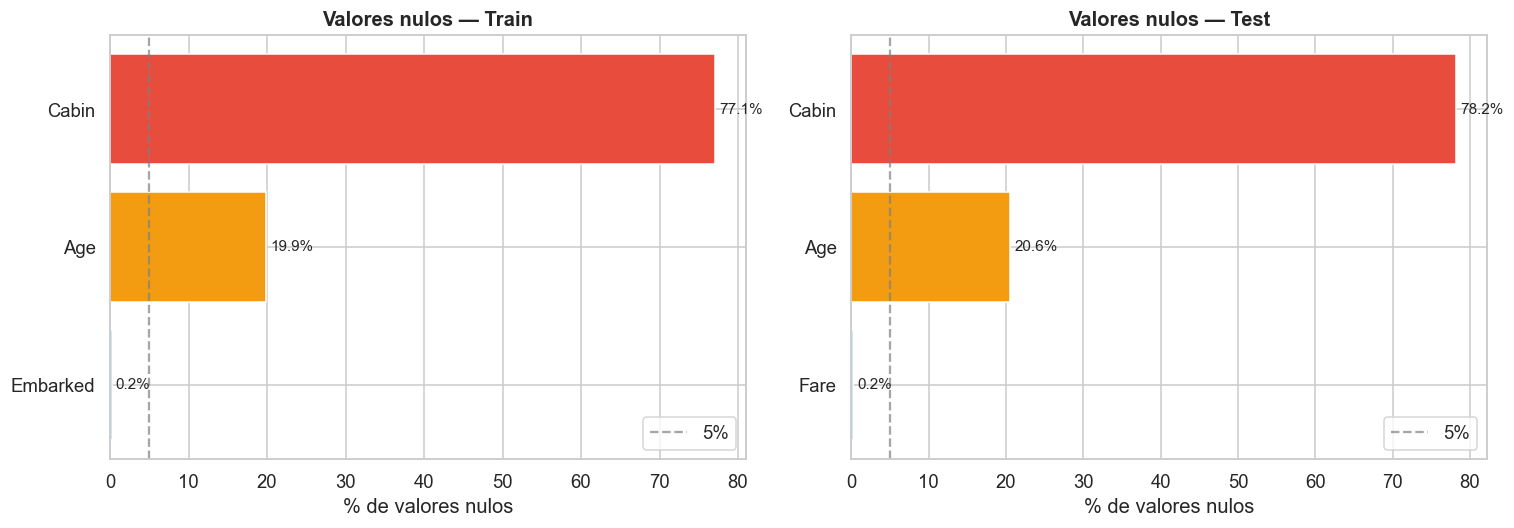

Gráfico guardado en output/eda_nulos.png


In [6]:
# Visualización de nulos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, name) in zip(axes, [(train_raw, 'Train'), (test_raw, 'Test')]):
    pct_nulos = df.isnull().mean() * 100
    pct_nulos = pct_nulos[pct_nulos > 0].sort_values(ascending=True)
    bars = ax.barh(pct_nulos.index, pct_nulos.values,
                   color=['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db'
                          for v in pct_nulos.values])
    ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='5%')
    ax.set_xlabel('% de valores nulos')
    ax.set_title(f'Valores nulos — {name}', fontweight='bold')
    for bar, val in zip(bars, pct_nulos.values):
        ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=10)
    ax.legend()

plt.tight_layout()
plt.savefig('../output/eda_nulos.png', bbox_inches='tight', dpi=120)
plt.show()
print("Gráfico guardado en output/eda_nulos.png")


**Conclusiones sobre los valores nulos:**
- **`Age`** (~20% en train): requiere imputación. Usaremos la mediana por grupo (Pclass + Sex + Título) para mayor precisión.
- **`Cabin`** (~77% en train): demasiados nulos para imputar. Crearemos una variable binaria `HasCabin`.
- **`Embarked`** (solo 2 en train): imputaremos con la moda (Southampton = 'S').
- **`Fare`** (1 en test): imputaremos con la mediana de su Pclass.


### 2.2 Variable objetivo — Distribución de supervivencia


In [7]:
# Distribución general
survived_counts = train_raw['Survived'].value_counts()
survived_pct    = train_raw['Survived'].value_counts(normalize=True) * 100

print("DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Survived)")
print("=" * 50)
print(f"  No sobrevivieron (0): {survived_counts[0]:>4}  ({survived_pct[0]:.1f}%)")
print(f"  Sobrevivieron    (1): {survived_counts[1]:>4}  ({survived_pct[1]:.1f}%)")
print(f"  TOTAL:                {len(train_raw):>4}")
print()
print(f"  Tasa de supervivencia: {survived_pct[1]:.1f}%")
print(f"  → El dataset está desequilibrado: hay más fallecidos que supervivientes.")


DISTRIBUCIÓN DE LA VARIABLE OBJETIVO (Survived)
  No sobrevivieron (0):  549  (61.6%)
  Sobrevivieron    (1):  342  (38.4%)
  TOTAL:                 891

  Tasa de supervivencia: 38.4%
  → El dataset está desequilibrado: hay más fallecidos que supervivientes.


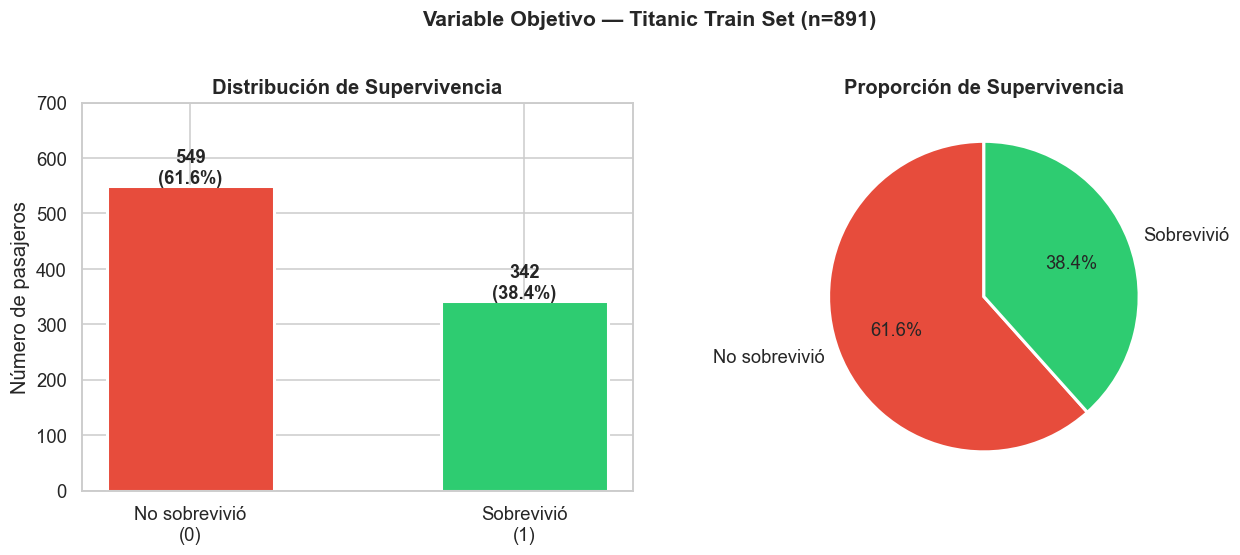

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barras
colores = ['#e74c3c', '#2ecc71']
axes[0].bar(['No sobrevivió\n(0)', 'Sobrevivió\n(1)'],
            survived_counts.values,
            color=colores, width=0.5, edgecolor='white', linewidth=2)
for i, (val, pct) in enumerate(zip(survived_counts.values, survived_pct.values)):
    axes[0].text(i, val + 5, f'{val}\n({pct:.1f}%)',
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Número de pasajeros')
axes[0].set_title('Distribución de Supervivencia', fontweight='bold')
axes[0].set_ylim(0, 700)

# Pastel
axes[1].pie(survived_counts.values,
            labels=['No sobrevivió', 'Sobrevivió'],
            colors=colores, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2),
            textprops={'fontsize': 12})
axes[1].set_title('Proporción de Supervivencia', fontweight='bold')

plt.suptitle('Variable Objetivo — Titanic Train Set (n=891)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../output/eda_supervivencia.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.3 Supervivencia por género

El género es históricamente la variable más determinante en la supervivencia del Titanic debido al protocolo de evacuación "mujeres y niños primero".


In [9]:
# Tasa de supervivencia por género
surv_genero = train_raw.groupby('Sex')['Survived'].agg(['sum', 'count', 'mean'])
surv_genero.columns = ['Supervivientes', 'Total', 'Tasa']
surv_genero['Tasa_%'] = (surv_genero['Tasa'] * 100).round(1)
surv_genero['Fallecidos'] = surv_genero['Total'] - surv_genero['Supervivientes']

print("SUPERVIVENCIA POR GÉNERO")
print("=" * 55)
display(surv_genero[['Total', 'Supervivientes', 'Fallecidos', 'Tasa_%']])
print()
print(f"  Las mujeres tenían {surv_genero.loc['female','Tasa_%'] / surv_genero.loc['male','Tasa_%']:.1f}x más probabilidad de sobrevivir que los hombres.")


SUPERVIVENCIA POR GÉNERO


,Total,Supervivientes,Fallecidos,Tasa_%
Sex,,,,
female,314,233,81,74.2
male,577,109,468,18.9



  Las mujeres tenían 3.9x más probabilidad de sobrevivir que los hombres.


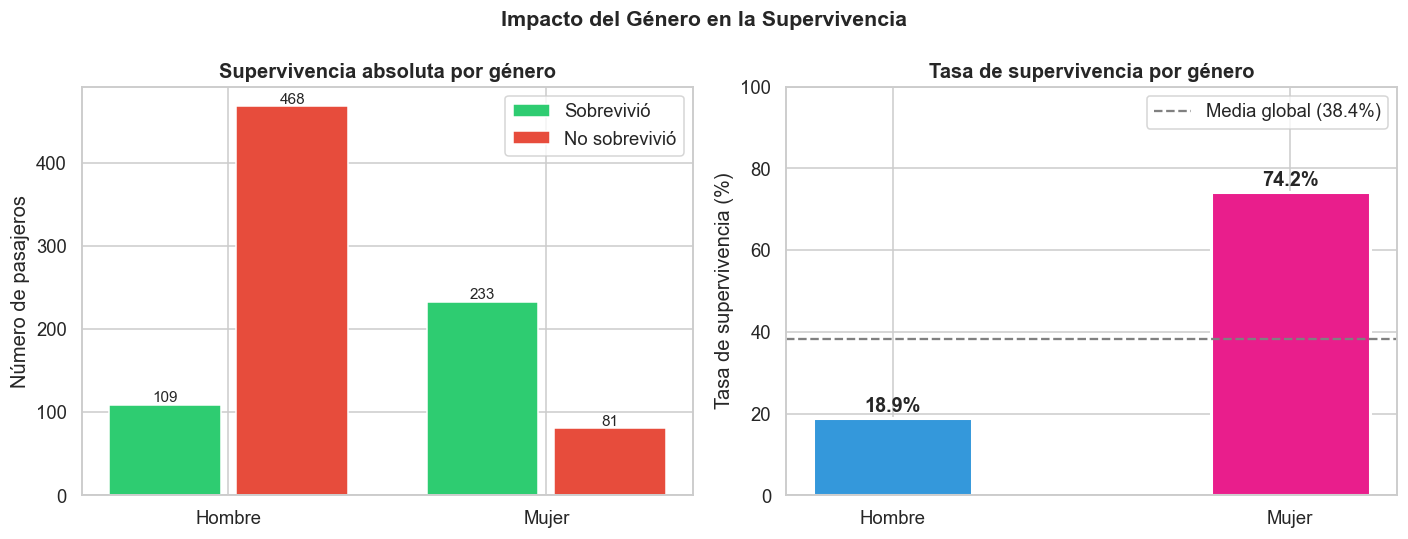

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras agrupadas
x = np.arange(2)
labels = ['Hombre', 'Mujer']
surv = [surv_genero.loc['male', 'Supervivientes'], surv_genero.loc['female', 'Supervivientes']]
fall = [surv_genero.loc['male', 'Fallecidos'],     surv_genero.loc['female', 'Fallecidos']]

b1 = axes[0].bar(x - 0.2, surv, 0.35, label='Sobrevivió', color='#2ecc71', edgecolor='white')
b2 = axes[0].bar(x + 0.2, fall, 0.35, label='No sobrevivió', color='#e74c3c', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel('Número de pasajeros')
axes[0].set_title('Supervivencia absoluta por género', fontweight='bold')
axes[0].legend()
for bar in list(b1) + list(b2):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 3,
                 str(int(bar.get_height())), ha='center', fontsize=10)

# Tasas
tasas = [surv_genero.loc['male', 'Tasa_%'], surv_genero.loc['female', 'Tasa_%']]
colores_barra = ['#3498db', '#e91e8c']
bars = axes[1].bar(labels, tasas, color=colores_barra, width=0.4, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Tasa de supervivencia (%)')
axes[1].set_title('Tasa de supervivencia por género', fontweight='bold')
axes[1].set_ylim(0, 100)
axes[1].axhline(y=train_raw['Survived'].mean()*100, color='gray',
                linestyle='--', label=f'Media global ({train_raw["Survived"].mean()*100:.1f}%)')
axes[1].legend()
for bar, val in zip(bars, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 1.5,
                 f'{val}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Impacto del Género en la Supervivencia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_genero.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.4 Supervivencia por clase de billete (Pclass)

La clase social determina tanto el nivel económico del pasajero como su ubicación física en el barco. Los pasajeros de 1ª clase tenían camarotes en cubiertas superiores, más cercanas a los botes salvavidas.


In [11]:
# Tasa por clase
surv_clase = train_raw.groupby('Pclass')['Survived'].agg(['sum', 'count', 'mean'])
surv_clase.columns = ['Supervivientes', 'Total', 'Tasa']
surv_clase['Tasa_%'] = (surv_clase['Tasa'] * 100).round(1)
surv_clase['Fallecidos'] = surv_clase['Total'] - surv_clase['Supervivientes']
surv_clase.index.name = 'Clase'

print("SUPERVIVENCIA POR CLASE DE BILLETE")
print("=" * 55)
display(surv_clase[['Total', 'Supervivientes', 'Fallecidos', 'Tasa_%']])
print()
print("Interpretación:")
print(f"  1ª clase: {surv_clase.loc[1,'Tasa_%']}% de supervivencia → posición privilegiada, mayor acceso a botes")
print(f"  2ª clase: {surv_clase.loc[2,'Tasa_%']}% de supervivencia → clase media")
print(f"  3ª clase: {surv_clase.loc[3,'Tasa_%']}% de supervivencia → cubiertas inferiores, mayor distancia a botes")


SUPERVIVENCIA POR CLASE DE BILLETE


,Total,Supervivientes,Fallecidos,Tasa_%
Clase,,,,
1,216,136,80,63.0
2,184,87,97,47.3
3,491,119,372,24.2



Interpretación:
  1ª clase: 63.0% de supervivencia → posición privilegiada, mayor acceso a botes
  2ª clase: 47.3% de supervivencia → clase media
  3ª clase: 24.2% de supervivencia → cubiertas inferiores, mayor distancia a botes


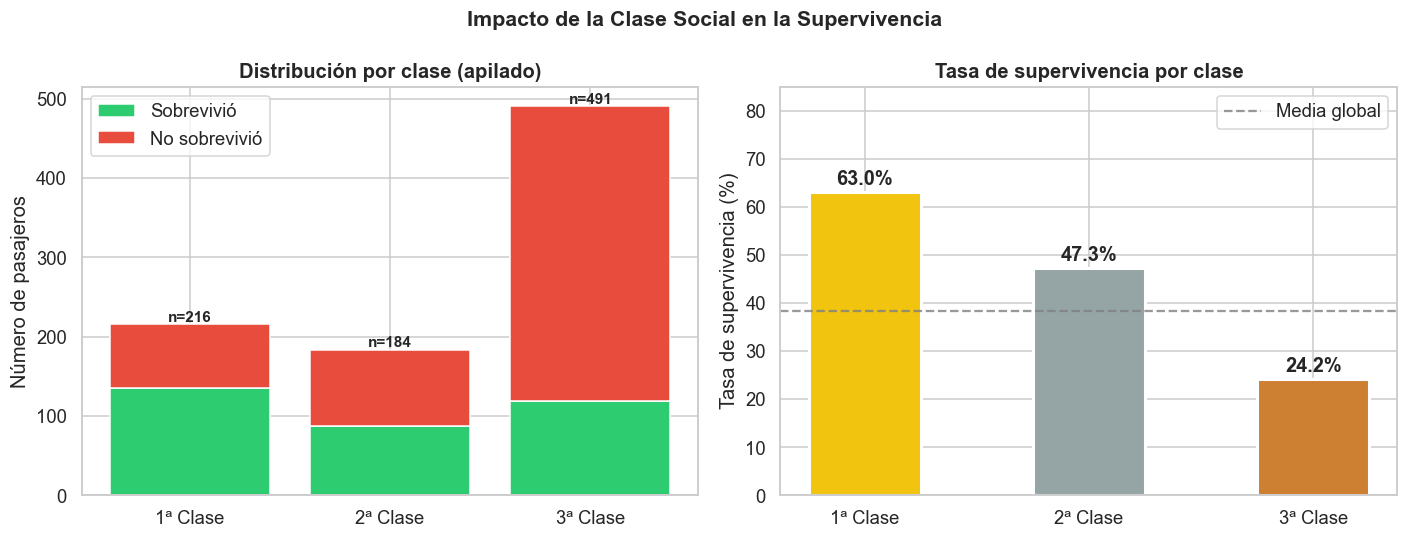

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

clases = ['1ª Clase', '2ª Clase', '3ª Clase']
tasas  = surv_clase['Tasa_%'].values
totals = surv_clase['Total'].values
survs  = surv_clase['Supervivientes'].values
falls  = surv_clase['Fallecidos'].values

# Stacked bar
axes[0].bar(clases, survs, label='Sobrevivió',    color='#2ecc71', edgecolor='white')
axes[0].bar(clases, falls, bottom=survs,           label='No sobrevivió', color='#e74c3c', edgecolor='white')
for i, (s, f, t) in enumerate(zip(survs, falls, totals)):
    axes[0].text(i, t + 3, f'n={t}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Número de pasajeros')
axes[0].set_title('Distribución por clase (apilado)', fontweight='bold')
axes[0].legend()

# Tasas
colores = ['#f1c40f', '#95a5a6', '#cd7f32']
bars = axes[1].bar(clases, tasas, color=colores, width=0.5, edgecolor='white', linewidth=2)
axes[1].set_ylabel('Tasa de supervivencia (%)')
axes[1].set_title('Tasa de supervivencia por clase', fontweight='bold')
axes[1].set_ylim(0, 85)
axes[1].axhline(y=train_raw['Survived'].mean()*100, color='gray',
                linestyle='--', alpha=0.8, label='Media global')
axes[1].legend()
for bar, val in zip(bars, tasas):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 1.5,
                 f'{val}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Impacto de la Clase Social en la Supervivencia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_clase.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.5 Supervivencia por edad

La edad tiene un patrón complejo. Los niños tenían prioridad de evacuación, pero la distribución de edad entre clases sociales también afecta al resultado.


In [13]:
# Estadísticas de edad
print("ESTADÍSTICAS DE EDAD")
print("=" * 50)
print(f"  Edad media (total):         {train_raw['Age'].mean():.1f} años")
print(f"  Edad mediana (total):       {train_raw['Age'].median():.1f} años")
print(f"  Rango:                      {train_raw['Age'].min():.0f} – {train_raw['Age'].max():.0f} años")
print(f"  Valores nulos:              {train_raw['Age'].isnull().sum()} ({train_raw['Age'].isnull().mean()*100:.1f}%)")
print()

print("EDAD MEDIA POR SUPERVIVENCIA:")
print(train_raw.groupby('Survived')['Age'].agg(['mean','median','std']).round(2).rename(
    index={0: 'No sobrevivió', 1: 'Sobrevivió'}).to_string())
print()

print("EDAD MEDIA POR CLASE:")
print(train_raw.groupby('Pclass')['Age'].agg(['mean','median','count']).round(2).rename(
    index={1: '1ª Clase', 2: '2ª Clase', 3: '3ª Clase'}).to_string())


ESTADÍSTICAS DE EDAD
  Edad media (total):         29.7 años
  Edad mediana (total):       28.0 años
  Rango:                      0 – 80 años
  Valores nulos:              177 (19.9%)

EDAD MEDIA POR SUPERVIVENCIA:
                mean  median    std
Survived                           
No sobrevivió  30.63    28.0  14.17
Sobrevivió     28.34    28.0  14.95

EDAD MEDIA POR CLASE:
           mean  median  count
Pclass                        
1ª Clase  38.23    37.0    186
2ª Clase  29.88    29.0    173
3ª Clase  25.14    24.0    355


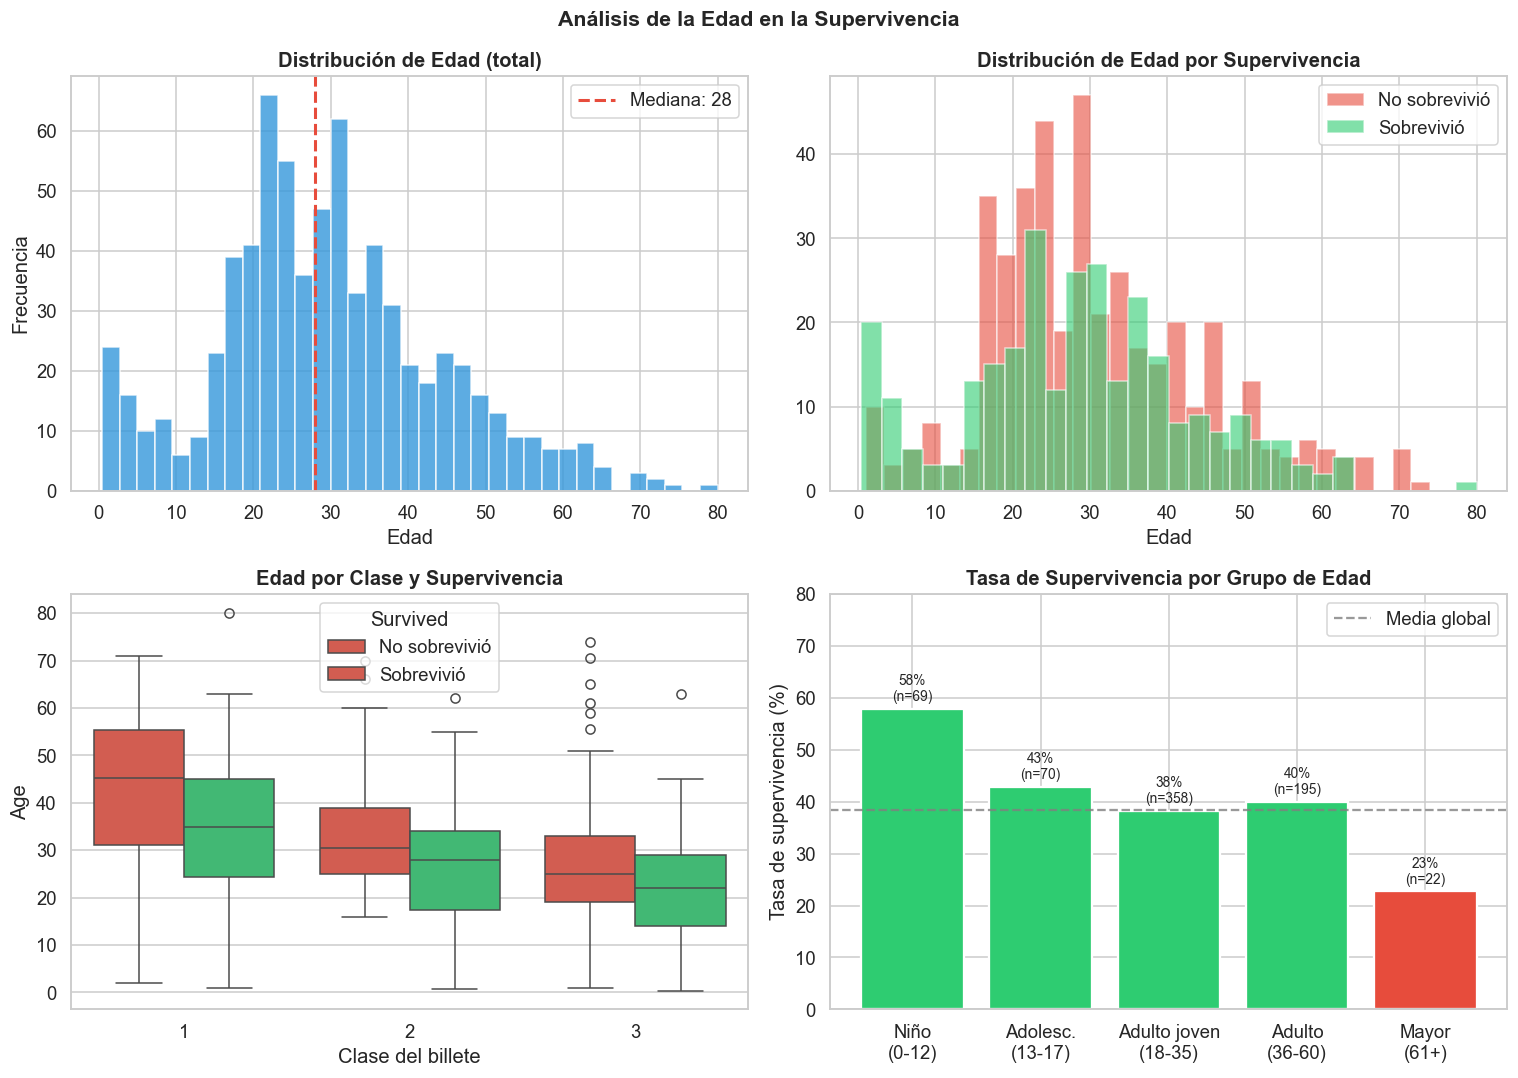

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribución de edad total
axes[0,0].hist(train_raw['Age'].dropna(), bins=35, color='#3498db',
               edgecolor='white', alpha=0.8)
axes[0,0].axvline(train_raw['Age'].median(), color='#e74c3c', linestyle='--',
                  linewidth=2, label=f'Mediana: {train_raw["Age"].median():.0f}')
axes[0,0].set_xlabel('Edad')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].set_title('Distribución de Edad (total)', fontweight='bold')
axes[0,0].legend()

# Distribución por supervivencia (KDE)
for surv, label, color in [(0, 'No sobrevivió', '#e74c3c'), (1, 'Sobrevivió', '#2ecc71')]:
    data = train_raw[train_raw['Survived'] == surv]['Age'].dropna()
    axes[0,1].hist(data, bins=30, alpha=0.6, label=label, color=color, edgecolor='white')
axes[0,1].set_xlabel('Edad')
axes[0,1].set_title('Distribución de Edad por Supervivencia', fontweight='bold')
axes[0,1].legend()

# Boxplot edad por clase y supervivencia
sns.boxplot(data=train_raw, x='Pclass', y='Age', hue='Survived',
            palette={0: '#e74c3c', 1: '#2ecc71'},
            ax=axes[1,0])
axes[1,0].set_xlabel('Clase del billete')
axes[1,0].set_title('Edad por Clase y Supervivencia', fontweight='bold')
axes[1,0].legend(title='Survived', labels=['No sobrevivió', 'Sobrevivió'])

# Supervivencia por grupo de edad
bins = [0, 12, 18, 35, 60, 100]
labels = ['Niño\n(0-12)', 'Adolesc.\n(13-17)', 'Adulto joven\n(18-35)',
          'Adulto\n(36-60)', 'Mayor\n(61+)']
train_raw['AgeGroup_tmp'] = pd.cut(train_raw['Age'], bins=bins, labels=labels)
surv_age = train_raw.groupby('AgeGroup_tmp', observed=True)['Survived'].mean() * 100
counts   = train_raw.groupby('AgeGroup_tmp', observed=True)['Survived'].count()

bars = axes[1,1].bar(surv_age.index, surv_age.values,
                     color=['#2ecc71' if v >= 38 else '#e74c3c' for v in surv_age.values],
                     edgecolor='white', linewidth=1.5)
for bar, val, cnt in zip(bars, surv_age.values, counts.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2., val + 1.5,
                   f'{val:.0f}%\n(n={cnt})', ha='center', fontsize=9)
axes[1,1].axhline(y=train_raw['Survived'].mean()*100, color='gray',
                  linestyle='--', alpha=0.8, label='Media global')
axes[1,1].set_ylabel('Tasa de supervivencia (%)')
axes[1,1].set_title('Tasa de Supervivencia por Grupo de Edad', fontweight='bold')
axes[1,1].set_ylim(0, 80)
axes[1,1].legend()

train_raw.drop(columns=['AgeGroup_tmp'], inplace=True)

plt.suptitle('Análisis de la Edad en la Supervivencia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_edad.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.6 Supervivencia por tamaño familiar y viaje en solitario


In [15]:
# Análisis de familia
train_raw['FamilySize_tmp'] = train_raw['SibSp'] + train_raw['Parch'] + 1

print("DISTRIBUCIÓN DEL TAMAÑO FAMILIAR:")
print("-" * 50)
fam_dist = train_raw['FamilySize_tmp'].value_counts().sort_index()
for size, count in fam_dist.items():
    pct = count / len(train_raw) * 100
    solo = "← Solo" if size == 1 else ""
    print(f"  Tamaño {size}: {count:>3} pasajeros ({pct:>4.1f}%) {solo}")

print()
surv_fam = train_raw.groupby('FamilySize_tmp')['Survived'].agg(['mean','count'])
surv_fam.columns = ['Tasa', 'Total']
surv_fam['Tasa_%'] = (surv_fam['Tasa'] * 100).round(1)
print("SUPERVIVENCIA POR TAMAÑO FAMILIAR:")
display(surv_fam)

print()
solo_tasa = train_raw[train_raw['FamilySize_tmp']==1]['Survived'].mean()*100
print(f"  Viajaban solos: {(train_raw['FamilySize_tmp']==1).sum()} pasajeros ({(train_raw['FamilySize_tmp']==1).mean()*100:.1f}%)")
print(f"  Tasa de supervivencia viajando solo: {solo_tasa:.1f}%")


DISTRIBUCIÓN DEL TAMAÑO FAMILIAR:
--------------------------------------------------
  Tamaño 1: 537 pasajeros (60.3%) ← Solo
  Tamaño 2: 161 pasajeros (18.1%) 
  Tamaño 3: 102 pasajeros (11.4%) 
  Tamaño 4:  29 pasajeros ( 3.3%) 
  Tamaño 5:  15 pasajeros ( 1.7%) 
  Tamaño 6:  22 pasajeros ( 2.5%) 
  Tamaño 7:  12 pasajeros ( 1.3%) 
  Tamaño 8:   6 pasajeros ( 0.7%) 
  Tamaño 11:   7 pasajeros ( 0.8%) 

SUPERVIVENCIA POR TAMAÑO FAMILIAR:


,Tasa,Total,Tasa_%
FamilySize_tmp,,,
1,0.303538,537,30.4
2,0.552795,161,55.3
3,0.578431,102,57.8
4,0.724138,29,72.4
5,0.200000,15,20.0
6,0.136364,22,13.6
7,0.333333,12,33.3
8,0.000000,6,0.0
11,0.000000,7,0.0



  Viajaban solos: 537 pasajeros (60.3%)
  Tasa de supervivencia viajando solo: 30.4%


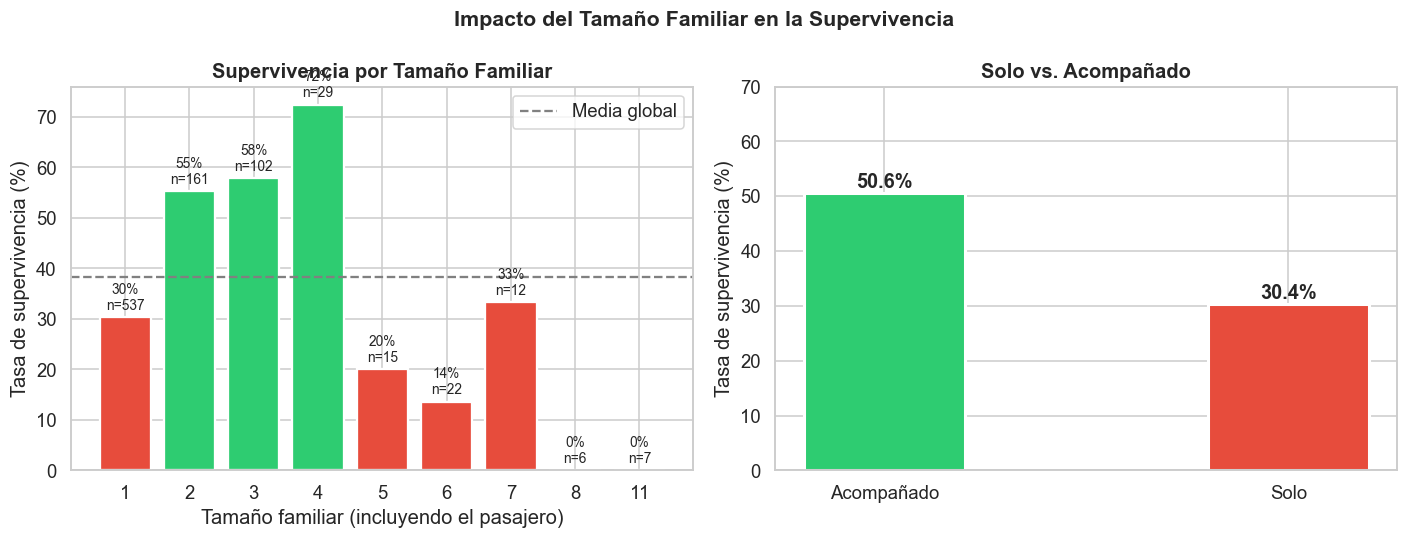

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tasa por tamaño familiar
fam_tasas = train_raw.groupby('FamilySize_tmp')['Survived'].mean() * 100
fam_counts = train_raw['FamilySize_tmp'].value_counts().sort_index()

colores = ['#e74c3c' if v < 38 else '#2ecc71' for v in fam_tasas.values]
bars = axes[0].bar(fam_tasas.index.astype(str), fam_tasas.values,
                   color=colores, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=train_raw['Survived'].mean()*100, color='gray',
                linestyle='--', label='Media global')
axes[0].set_xlabel('Tamaño familiar (incluyendo el pasajero)')
axes[0].set_ylabel('Tasa de supervivencia (%)')
axes[0].set_title('Supervivencia por Tamaño Familiar', fontweight='bold')
axes[0].legend()
for bar, (size, val) in zip(bars, fam_tasas.items()):
    n = fam_counts.get(size, 0)
    axes[0].text(bar.get_x() + bar.get_width()/2., val + 1.5,
                 f'{val:.0f}%\nn={n}', ha='center', fontsize=9)

# Solo vs acompañado
train_raw['IsAlone_tmp'] = (train_raw['FamilySize_tmp'] == 1).astype(int)
surv_solo = train_raw.groupby('IsAlone_tmp')['Survived'].mean() * 100
labels_solo = ['Acompañado', 'Solo']
bars2 = axes[1].bar(labels_solo, surv_solo.values,
                    color=['#2ecc71', '#e74c3c'], width=0.4,
                    edgecolor='white', linewidth=2)
for bar, val in zip(bars2, surv_solo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2., val + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Tasa de supervivencia (%)')
axes[1].set_title('Solo vs. Acompañado', fontweight='bold')
axes[1].set_ylim(0, 70)

train_raw.drop(columns=['FamilySize_tmp', 'IsAlone_tmp'], inplace=True, errors='ignore')

plt.suptitle('Impacto del Tamaño Familiar en la Supervivencia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_familia.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.7 Supervivencia por puerto de embarque y tarifa


In [17]:
# Puerto de embarque
print("DISTRIBUCIÓN POR PUERTO DE EMBARQUE:")
print("-" * 55)
emb_info = train_raw.groupby('Embarked').agg(
    Total=('Survived','count'),
    Supervivientes=('Survived','sum'),
    Tasa_pct=('Survived', lambda x: round(x.mean()*100,1)),
    Tarifa_media=('Fare', 'mean')
).round(2)
emb_info.index = ['Cherbourg (C)', 'Queenstown (Q)', 'Southampton (S)']
display(emb_info)

print()
print("Nota: Cherbourg tiene mayor tasa de supervivencia porque embarcaron")
print("más pasajeros de 1ª clase en ese puerto.")
print()
print("ESTADÍSTICAS DE TARIFA POR SUPERVIVENCIA:")
print(train_raw.groupby('Survived')['Fare'].describe().round(2).rename(
    index={0: 'No sobrevivió', 1: 'Sobrevivió'}).to_string())


DISTRIBUCIÓN POR PUERTO DE EMBARQUE:
-------------------------------------------------------


,Total,Supervivientes,Tasa_pct,Tarifa_media
Cherbourg (C),168,93,55.4,59.95
Queenstown (Q),77,30,39.0,13.28
Southampton (S),644,217,33.7,27.08



Nota: Cherbourg tiene mayor tasa de supervivencia porque embarcaron
más pasajeros de 1ª clase en ese puerto.

ESTADÍSTICAS DE TARIFA POR SUPERVIVENCIA:
               count   mean    std  min    25%   50%   75%     max
Survived                                                          
No sobrevivió  549.0  22.12  31.39  0.0   7.85  10.5  26.0  263.00
Sobrevivió     342.0  48.40  66.60  0.0  12.48  26.0  57.0  512.33


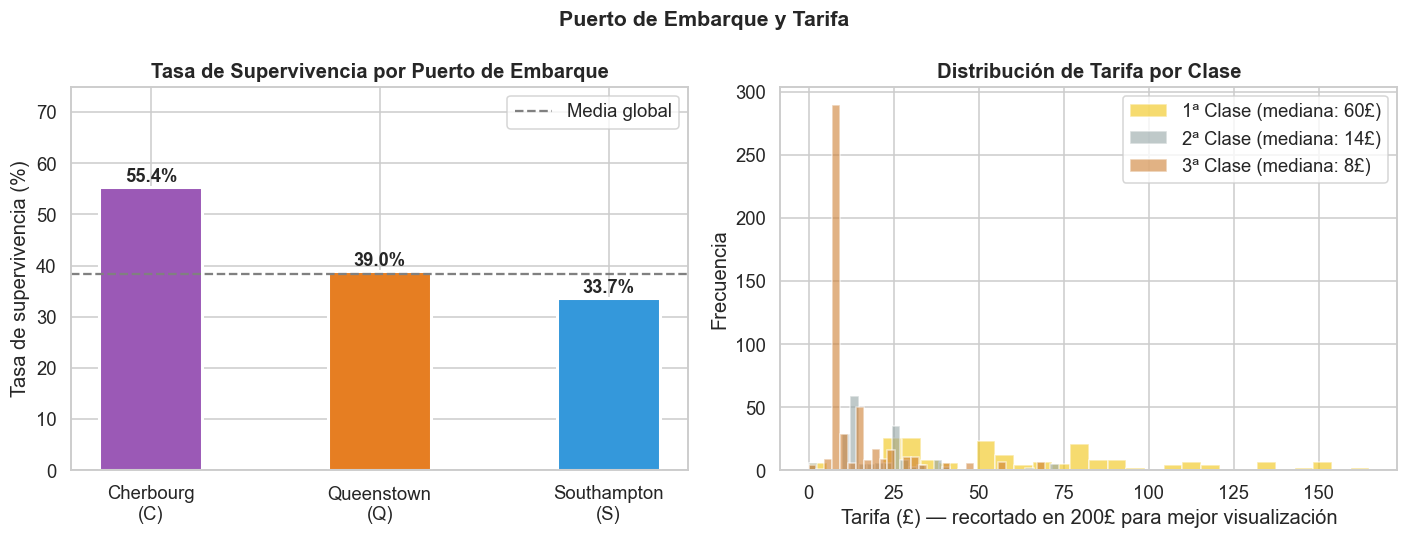

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tasa por puerto
puertos = ['Cherbourg\n(C)', 'Queenstown\n(Q)', 'Southampton\n(S)']
tasas_emb = train_raw.groupby('Embarked')['Survived'].mean() * 100
colores_emb = ['#9b59b6', '#e67e22', '#3498db']
bars = axes[0].bar(puertos, tasas_emb.values, color=colores_emb,
                   width=0.45, edgecolor='white', linewidth=2)
axes[0].axhline(y=train_raw['Survived'].mean()*100, color='gray',
                linestyle='--', label='Media global')
axes[0].set_ylabel('Tasa de supervivencia (%)')
axes[0].set_title('Tasa de Supervivencia por Puerto de Embarque', fontweight='bold')
axes[0].set_ylim(0, 75)
axes[0].legend()
for bar, val in zip(bars, tasas_emb.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., val + 1,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')

# Fare distribution por clase
for cls, color in [(1,'#f1c40f'), (2,'#95a5a6'), (3,'#cd7f32')]:
    data = train_raw[train_raw['Pclass']==cls]['Fare']
    data_clipped = data[data < 200]
    axes[1].hist(data_clipped, bins=30, alpha=0.6,
                 label=f'{cls}ª Clase (mediana: {data.median():.0f}£)',
                 color=color, edgecolor='white')
axes[1].set_xlabel('Tarifa (£) — recortado en 200£ para mejor visualización')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Tarifa por Clase', fontweight='bold')
axes[1].legend()

plt.suptitle('Puerto de Embarque y Tarifa', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/eda_embarque_tarifa.png', bbox_inches='tight', dpi=120)
plt.show()


### 2.8 Mapa de calor — Supervivencia por Género × Clase

Esta tabla cruzada muestra claramente cómo la combinación de género y clase determinó la probabilidad de sobrevivir.


In [19]:
# Pivot table: supervivencia media por género y clase
pivot = train_raw.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
pivot.index = ['Mujer', 'Hombre']
pivot.columns = ['1ª Clase', '2ª Clase', '3ª Clase']
pivot = pivot.round(1)

print("TASA DE SUPERVIVENCIA (%) — GÉNERO × CLASE")
print("=" * 50)
display(pivot)
print()
print("→ Una mujer de 1ª clase tenía un {:.0f}% de probabilidad de sobrevivir.".format(pivot.loc['Mujer','1ª Clase']))
print("→ Un hombre de 3ª clase tenía solo un {:.0f}% de probabilidad.".format(pivot.loc['Hombre','3ª Clase']))

# También el total de pasajeros por grupo
pivot_count = train_raw.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='count')
pivot_count.index = ['Mujer', 'Hombre']
pivot_count.columns = ['1ª Clase', '2ª Clase', '3ª Clase']
print("\nNÚMERO DE PASAJEROS POR GRUPO:")
display(pivot_count)


TASA DE SUPERVIVENCIA (%) — GÉNERO × CLASE


,1ª Clase,2ª Clase,3ª Clase
Mujer,96.8,92.1,50.0
Hombre,36.9,15.7,13.5



→ Una mujer de 1ª clase tenía un 97% de probabilidad de sobrevivir.
→ Un hombre de 3ª clase tenía solo un 14% de probabilidad.

NÚMERO DE PASAJEROS POR GRUPO:


,1ª Clase,2ª Clase,3ª Clase
Mujer,94,76,144
Hombre,122,108,347


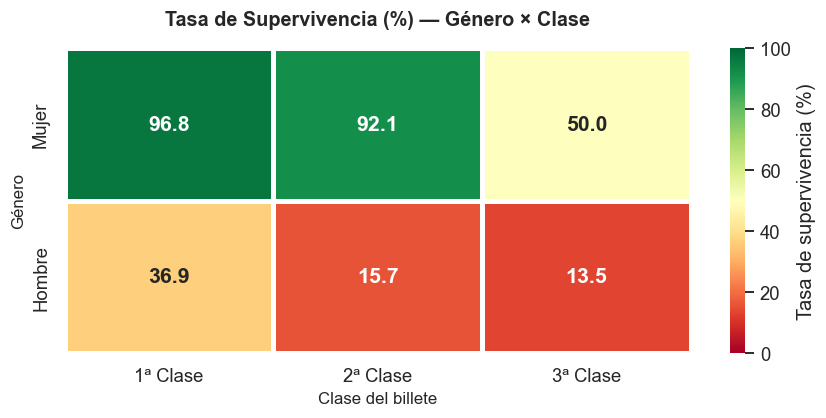

→ El color verde indica mayor supervivencia, rojo menor.


In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='RdYlGn',
            linewidths=2, linecolor='white',
            vmin=0, vmax=100, ax=ax,
            annot_kws={'size': 14, 'weight': 'bold'},
            cbar_kws={'label': 'Tasa de supervivencia (%)'})
ax.set_title('Tasa de Supervivencia (%) — Género × Clase', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Clase del billete', fontsize=11)
ax.set_ylabel('Género', fontsize=11)
plt.tight_layout()
plt.savefig('../output/eda_heatmap_genero_clase.png', bbox_inches='tight', dpi=120)
plt.show()
print("→ El color verde indica mayor supervivencia, rojo menor.")


---
## Sección 3: Limpieza de Datos y Feature Engineering

En esta sección tratamos los valores nulos y creamos nuevas variables que enriquecerán el modelo predictivo. El feature engineering es una de las fases más importantes del proceso de Machine Learning.

**Estrategia:** Trabajaremos sobre una copia del dataset para no alterar los datos originales. Aplicaremos las mismas transformaciones a train y test para garantizar consistencia.


In [21]:
# Creamos copias de trabajo
train = train_raw.copy()
test  = test_raw.copy()

# Combinamos temporalmente para aplicar transformaciones coherentes
# (importante para que los estadísticos sean los mismos en ambos conjuntos)
test['Survived'] = np.nan
combined = pd.concat([train, test], axis=0, ignore_index=True)
print(f"Dataset combinado: {combined.shape[0]} filas × {combined.shape[1]} columnas")
print(f"  → Train: primeras {len(train)} filas")
print(f"  → Test:  últimas {len(test)} filas")


Dataset combinado: 1309 filas × 12 columnas
  → Train: primeras 891 filas
  → Test:  últimas 418 filas


### 3.1 Extracción del Título social del nombre

El nombre de cada pasajero contiene un título honorífico (Mr., Mrs., Miss., Master., Dr., etc.) que es un indicador muy potente: revela género, estado civil, edad aproximada y posición social.


In [22]:
# Extraer título del nombre
combined['Title'] = combined['Name'].str.extract(r',\s*([A-Za-z]+)\.', expand=False)

print("FRECUENCIA DE TÍTULOS EN EL DATASET COMBINADO:")
print("-" * 45)
title_counts = combined['Title'].value_counts()
display(title_counts.to_frame('Frecuencia'))


FRECUENCIA DE TÍTULOS EN EL DATASET COMBINADO:
---------------------------------------------


,Frecuencia
Title,
Mr,757
Miss,260
Mrs,197
Master,61
Rev,8
Dr,8
Col,4
Major,2
Ms,2


In [23]:
# Agrupar títulos raros en categorías
title_map = {
    'Mr':     'Mr',
    'Miss':   'Miss',
    'Mrs':    'Mrs',
    'Master': 'Master',   # Niños varones
    # Todos los demás → 'Rare' (oficiales, aristocracia, religiosos, etc.)
}
combined['Title'] = combined['Title'].map(title_map).fillna('Rare')

print("TÍTULOS DESPUÉS DE AGRUPACIÓN:")
print("-" * 50)
print(combined['Title'].value_counts().to_frame('Frecuencia'))
print()
print("Interpretación:")
print("  Mr     → Hombre adulto")
print("  Mrs    → Mujer casada (adulta)")
print("  Miss   → Mujer soltera o niña")
print("  Master → Niño varón (≤ ~14 años)")
print("  Rare   → Títulos poco comunes: Dr., Rev., Col., Countess., etc.")

# Tasa de supervivencia por título (solo train)
train_with_title = combined[combined['Survived'].notna()].copy()
print("\nTASA DE SUPERVIVENCIA POR TÍTULO:")
surv_title = train_with_title.groupby('Title')['Survived'].agg(['mean','count'])
surv_title.columns = ['Tasa', 'Total']
surv_title['Tasa_%'] = (surv_title['Tasa'] * 100).round(1)
display(surv_title.sort_values('Tasa', ascending=False))


TÍTULOS DESPUÉS DE AGRUPACIÓN:
--------------------------------------------------
        Frecuencia
Title             
Mr             757
Miss           260
Mrs            197
Master          61
Rare            34

Interpretación:
  Mr     → Hombre adulto
  Mrs    → Mujer casada (adulta)
  Miss   → Mujer soltera o niña
  Master → Niño varón (≤ ~14 años)
  Rare   → Títulos poco comunes: Dr., Rev., Col., Countess., etc.

TASA DE SUPERVIVENCIA POR TÍTULO:


,Tasa,Total,Tasa_%
Title,,,
Mrs,0.792000,125,79.2
Miss,0.697802,182,69.8
Master,0.575000,40,57.5
Rare,0.444444,27,44.4
Mr,0.156673,517,15.7


### 3.2 Imputación de Edad

Con el 20% de valores nulos, la imputación de la edad debe ser cuidadosa. Usamos la **mediana por grupo (Título + Pclass)** en lugar de la mediana global, ya que sabemos que los "Master" son niños y los "Mr" son adultos.


In [24]:
# Mediana de edad por Título + Pclass
age_medians = combined.groupby(['Title', 'Pclass'])['Age'].median()
print("MEDIANA DE EDAD POR TÍTULO Y CLASE:")
print("-" * 50)
display(age_medians.unstack('Pclass').round(1))


MEDIANA DE EDAD POR TÍTULO Y CLASE:
--------------------------------------------------


Pclass,1,2,3
Title,,,
Master,6.0,2.0,6.0
Miss,30.0,20.0,18.0
Mr,41.5,30.0,26.0
Mrs,45.0,30.5,31.0
Rare,47.0,41.0,NaN


In [25]:
# Imputar los nulos
def imputar_edad(row):
    if pd.isna(row['Age']):
        try:
            return age_medians.loc[(row['Title'], row['Pclass'])]
        except KeyError:
            return combined.groupby('Title')['Age'].median().get(row['Title'],
                   combined['Age'].median())
    return row['Age']

n_nulos_antes = combined['Age'].isnull().sum()
combined['Age'] = combined.apply(imputar_edad, axis=1)
n_nulos_despues = combined['Age'].isnull().sum()

print(f"Valores nulos en Age antes:  {n_nulos_antes}")
print(f"Valores nulos en Age después: {n_nulos_despues}")
print(f"→ {n_nulos_antes - n_nulos_despues} valores imputados correctamente.")


Valores nulos en Age antes:  263
Valores nulos en Age después: 1
→ 262 valores imputados correctamente.


### 3.3 Imputación de Embarked y Fare


In [26]:
# Embarked: 2 nulos → imputar con moda (Southampton)
moda_embarked = combined['Embarked'].mode()[0]
combined['Embarked'].fillna(moda_embarked, inplace=True)
print(f"Embarked: 2 nulos imputados con '{moda_embarked}' (moda del dataset)")

# Fare: 1 nulo en test → mediana de su clase
fare_medians = combined.groupby('Pclass')['Fare'].median()
def imputar_fare(row):
    if pd.isna(row['Fare']):
        return fare_medians[row['Pclass']]
    return row['Fare']
combined['Fare'] = combined.apply(imputar_fare, axis=1)
print(f"Fare: nulos imputados con mediana por clase:")
print(fare_medians.to_frame('Mediana Fare (£)').to_string())
print()
print("Estado de nulos después de imputaciones:")
nulos_restantes = combined[['Age','Embarked','Fare']].isnull().sum()
print(nulos_restantes.to_frame('Nulos restantes').to_string())


Embarked: 2 nulos imputados con 'S' (moda del dataset)
Fare: nulos imputados con mediana por clase:
        Mediana Fare (£)
Pclass                  
1                60.0000
2                15.0458
3                 8.0500

Estado de nulos después de imputaciones:
          Nulos restantes
Age                     1
Embarked                0
Fare                    0


### 3.4 Variable `HasCabin` — Indicador de cabina conocida

Con un 77% de nulos, la columna `Cabin` no es útil directamente. Sin embargo, el hecho de **tener** una cabina registrada está correlacionado con la clase social y la posición en el barco.


In [27]:
combined['HasCabin'] = combined['Cabin'].notna().astype(int)
combined['Deck'] = combined['Cabin'].str.extract(r'^([A-Za-z])', expand=False).fillna('Unknown')

print("DISTRIBUCIÓN DE HasCabin:")
print(combined['HasCabin'].value_counts().to_frame('Frecuencia').to_string())
print()
print("TASA DE SUPERVIVENCIA POR HAS_CABIN (train):")
hc_surv = combined[combined['Survived'].notna()].groupby('HasCabin')['Survived'].mean() * 100
print(hc_surv.rename({0:'Sin cabina', 1:'Con cabina'}).to_frame('Tasa %').round(1).to_string())
print()
print("DISTRIBUCIÓN POR CUBIERTA (Deck):")
print(combined['Deck'].value_counts().to_frame('Frecuencia').to_string())


DISTRIBUCIÓN DE HasCabin:
          Frecuencia
HasCabin            
0               1014
1                295

TASA DE SUPERVIVENCIA POR HAS_CABIN (train):
            Tasa %
HasCabin          
Sin cabina    30.0
Con cabina    66.7

DISTRIBUCIÓN POR CUBIERTA (Deck):
         Frecuencia
Deck               
Unknown        1014
C                94
B                65
D                46
E                41
A                22
F                21
G                 5
T                 1


### 3.5 Creación de variables de familia


In [28]:
# Tamaño familiar total
combined['FamilySize'] = combined['SibSp'] + combined['Parch'] + 1

# Viajaba solo
combined['IsAlone'] = (combined['FamilySize'] == 1).astype(int)

# Categoría de familia
def cat_familia(size):
    if size == 1:    return 'Solo'
    elif size <= 4:  return 'Familia pequeña'
    else:            return 'Familia grande'

combined['FamilyCat'] = combined['FamilySize'].apply(cat_familia)

print("NUEVAS VARIABLES DE FAMILIA:")
print("-" * 50)
print(f"FamilySize  — Rango: {combined['FamilySize'].min()} a {combined['FamilySize'].max()}")
print()
print("IsAlone:")
print(combined['IsAlone'].value_counts().rename({0:'Acompañado', 1:'Solo'}).to_frame('Frecuencia').to_string())
print()
print("FamilyCat:")
print(combined['FamilyCat'].value_counts().to_frame('Frecuencia').to_string())
print()
print("TASA DE SUPERVIVENCIA POR CATEGORÍA FAMILIAR (train):")
fc_surv = combined[combined['Survived'].notna()].groupby('FamilyCat')['Survived'].mean()*100
print(fc_surv.round(1).to_frame('Tasa %').to_string())


NUEVAS VARIABLES DE FAMILIA:
--------------------------------------------------
FamilySize  — Rango: 1 a 11

IsAlone:
            Frecuencia
IsAlone               
Solo               790
Acompañado         519

FamilyCat:
                 Frecuencia
FamilyCat                  
Solo                    790
Familia pequeña         437
Familia grande           82

TASA DE SUPERVIVENCIA POR CATEGORÍA FAMILIAR (train):
                 Tasa %
FamilyCat              
Familia grande     16.1
Familia pequeña    57.9
Solo               30.4


### 3.6 Grupos de edad y tarifa


In [29]:
# Grupo de edad
age_bins   = [0, 12, 18, 35, 60, 100]
age_labels = ['Niño', 'Adolescente', 'Adulto joven', 'Adulto', 'Mayor']
combined['AgeGroup'] = pd.cut(combined['Age'], bins=age_bins, labels=age_labels)

# Grupo de tarifa (cuartiles)
combined['FareBand'] = pd.qcut(combined['Fare'], q=4,
                                labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto'])

print("DISTRIBUCIÓN POR GRUPO DE EDAD:")
print(combined['AgeGroup'].value_counts().sort_index().to_frame('Frecuencia').to_string())
print()
print("DISTRIBUCIÓN POR BANDA DE TARIFA:")
print(combined['FareBand'].value_counts().sort_index().to_frame('Frecuencia').to_string())
print()
print("TASA SUPERVIVENCIA POR GRUPO DE EDAD (train):")
age_surv = combined[combined['Survived'].notna()].groupby('AgeGroup', observed=True)['Survived'].mean()*100
print(age_surv.round(1).to_frame('Tasa %').to_string())


DISTRIBUCIÓN POR GRUPO DE EDAD:
              Frecuencia
AgeGroup                
Niño                 102
Adolescente          146
Adulto joven         700
Adulto               327
Mayor                 33

DISTRIBUCIÓN POR BANDA DE TARIFA:
            Frecuencia
FareBand              
Bajo               337
Medio-bajo         321
Medio-alto         328
Alto               323

TASA SUPERVIVENCIA POR GRUPO DE EDAD (train):
              Tasa %
AgeGroup            
Niño            57.5
Adolescente     47.6
Adulto joven    33.0
Adulto          40.6
Mayor           22.7


### 3.7 Codificación de variables categóricas

Los modelos de scikit-learn requieren que todas las variables sean numéricas.


In [30]:
# Codificación binaria y one-hot
combined['Sex_num'] = (combined['Sex'] == 'female').astype(int)  # 1=mujer, 0=hombre

le = LabelEncoder()
combined['Embarked_num'] = le.fit_transform(combined['Embarked'])  # C=0, Q=2, S=1 (alfabético)
combined['Title_num']    = le.fit_transform(combined['Title'])

# AgeGroup y FareBand → numérico ordinal
agegroup_map  = {'Niño': 0, 'Adolescente': 1, 'Adulto joven': 2, 'Adulto': 3, 'Mayor': 4}
fareband_map  = {'Bajo': 0, 'Medio-bajo': 1, 'Medio-alto': 2, 'Alto': 3}
familycat_map = {'Solo': 0, 'Familia pequeña': 1, 'Familia grande': 2}

combined['AgeGroup_num']  = combined['AgeGroup'].map(agegroup_map)
combined['FareBand_num']  = combined['FareBand'].map(fareband_map)
combined['FamilyCat_num'] = combined['FamilyCat'].map(familycat_map)

print("VARIABLES NUMÉRICAS DISPONIBLES PARA EL MODELO:")
print("-" * 55)
num_cols = ['Pclass','Sex_num','Age','SibSp','Parch','Fare',
            'Embarked_num','Title_num','HasCabin','FamilySize',
            'IsAlone','AgeGroup_num','FareBand_num','FamilyCat_num']
print(combined[num_cols].head(5).to_string())
print()
print(f"Total variables features: {len(num_cols)}")


VARIABLES NUMÉRICAS DISPONIBLES PARA EL MODELO:
-------------------------------------------------------
   Pclass  Sex_num   Age  SibSp  Parch     Fare  Embarked_num  Title_num  HasCabin  FamilySize  IsAlone AgeGroup_num FareBand_num  FamilyCat_num
0       3        0  22.0      1      0   7.2500             2          2         0           2        0            2            0              1
1       1        1  38.0      1      0  71.2833             0          3         1           2        0            3            3              1
2       3        1  26.0      0      0   7.9250             2          1         0           1        1            2            1              0
3       1        1  35.0      1      0  53.1000             2          3         1           2        0            2            3              1
4       3        0  35.0      0      0   8.0500             2          2         0           1        1            2            1              0

Total variables features:

### 3.8 Resumen del dataset limpio y enriquecido


In [31]:
print("RESUMEN FINAL DEL DATASET LIMPIO")
print("=" * 60)
print(f"Total filas (train+test): {len(combined)}")
print(f"Total columnas:           {len(combined.columns)}")
print()
print("NULOS RESTANTES EN VARIABLES CLAVE:")
key_cols = num_cols + ['Survived']
nulos_final = combined[key_cols].isnull().sum()
print(nulos_final[nulos_final > 0].to_frame('Nulos').to_string() or "  → Ningún nulo en variables del modelo")
print()
print("PRIMERAS 5 FILAS DEL DATASET PROCESADO:")
display(combined[['PassengerId','Survived','Pclass','Sex','Age','Title',
                  'FamilySize','IsAlone','FamilyCat','HasCabin','Fare',
                  'AgeGroup','FareBand','Embarked']].head())


RESUMEN FINAL DEL DATASET LIMPIO
Total filas (train+test): 1309
Total columnas:           26

NULOS RESTANTES EN VARIABLES CLAVE:
              Nulos
Age               1
AgeGroup_num      1
Survived        418

PRIMERAS 5 FILAS DEL DATASET PROCESADO:


,PassengerId,Survived,Pclass,Sex,Age,Title,FamilySize,IsAlone,FamilyCat,HasCabin,Fare,AgeGroup,FareBand,Embarked
0,1,0.0,3,male,22.0,Mr,2,0,Familia pequeña,0,7.2500,Adulto joven,Bajo,S
1,2,1.0,1,female,38.0,Mrs,2,0,Familia pequeña,1,71.2833,Adulto,Alto,C
2,3,1.0,3,female,26.0,Miss,1,1,Solo,0,7.9250,Adulto joven,Medio-bajo,S
3,4,1.0,1,female,35.0,Mrs,2,0,Familia pequeña,1,53.1000,Adulto joven,Alto,S
4,5,0.0,3,male,35.0,Mr,1,1,Solo,0,8.0500,Adulto joven,Medio-bajo,S


---
## Sección 4: Machine Learning

En esta sección construimos, evaluamos y comparamos varios modelos de clasificación para predecir la supervivencia de los pasajeros. El objetivo no es solo maximizar la precisión, sino entender **qué variables explican mejor la supervivencia**.

### 4.1 Preparación de las features para el modelo


In [32]:
# Features seleccionadas para el modelo
FEATURES = [
    'Pclass',         # Clase del billete (proxy nivel socioeconómico)
    'Sex_num',        # Género (1=mujer, 0=hombre)
    'Age',            # Edad
    'SibSp',          # Hermanos/cónyuge
    'Parch',          # Padres/hijos
    'Fare',           # Tarifa
    'Embarked_num',   # Puerto de embarque
    'Title_num',      # Título social
    'HasCabin',       # ¿Tiene cabina registrada?
    'FamilySize',     # Tamaño familiar
    'IsAlone',        # ¿Viajaba solo?
    'AgeGroup_num',   # Grupo de edad
    'FareBand_num',   # Banda de tarifa
]
TARGET = 'Survived'

# Separar train y test
train_df = combined[combined['Survived'].notna()].copy()
test_df  = combined[combined['Survived'].isna()].copy()

X = train_df[FEATURES]
y = train_df[TARGET].astype(int)
X_kaggle_test = test_df[FEATURES]

print(f"Conjunto de entrenamiento: {X.shape[0]} filas × {X.shape[1]} features")
print(f"Conjunto de test (Kaggle): {X_kaggle_test.shape[0]} filas")
print(f"Balance de clases: {y.value_counts().to_dict()} → {y.mean()*100:.1f}% supervivientes")
print()
print("FEATURES DEL MODELO:")
for i, feat in enumerate(FEATURES, 1):
    print(f"  {i:2}. {feat}")


Conjunto de entrenamiento: 891 filas × 13 features


Conjunto de test (Kaggle): 418 filas
Balance de clases: {0: 549, 1: 342} → 38.4% supervivientes

FEATURES DEL MODELO:
   1. Pclass
   2. Sex_num
   3. Age
   4. SibSp
   5. Parch
   6. Fare
   7. Embarked_num
   8. Title_num
   9. HasCabin
  10. FamilySize
  11. IsAlone
  12. AgeGroup_num
  13. FareBand_num


In [33]:
# División train / validación para evaluación local
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

print(f"Partición entrenamiento: {len(X_train)} muestras")
print(f"Partición validación:    {len(X_val)} muestras")
print()
print("Distribución en entrenamiento:")
print(y_train.value_counts().rename({0:'No sobrevivió', 1:'Sobrevivió'}).to_frame('Conteo').to_string())
print()
print("Distribución en validación:")
print(y_val.value_counts().rename({0:'No sobrevivió', 1:'Sobrevivió'}).to_frame('Conteo').to_string())


Partición entrenamiento: 712 muestras
Partición validación:    179 muestras

Distribución en entrenamiento:
               Conteo
Survived             
No sobrevivió     439
Sobrevivió        273

Distribución en validación:
               Conteo
Survived             
No sobrevivió     110
Sobrevivió         69


### 4.2 Baseline — Regresión Logística

La regresión logística es nuestro modelo base. Es interpretable, rápido y sirve como punto de referencia para los modelos más complejos.


In [34]:
# Regresión Logística
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)

lr_model = LogisticRegression(random_state=SEED, max_iter=1000, C=1.0)
lr_model.fit(X_train_sc, y_train)

lr_pred      = lr_model.predict(X_val_sc)
lr_prob      = lr_model.predict_proba(X_val_sc)[:, 1]
lr_acc       = accuracy_score(y_val, lr_pred)
lr_auc       = roc_auc_score(y_val, lr_prob)
lr_cv_scores = cross_val_score(lr_model, scaler.transform(X), y, cv=5,
                                scoring='accuracy', n_jobs=-1)

print("REGRESIÓN LOGÍSTICA — RESULTADOS")
print("=" * 50)
print(f"  Accuracy (validación):    {lr_acc:.4f}  ({lr_acc*100:.1f}%)")
print(f"  ROC-AUC (validación):     {lr_auc:.4f}")
print(f"  CV Accuracy (5-fold):     {lr_cv_scores.mean():.4f} ± {lr_cv_scores.std():.4f}")
print()
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_val, lr_pred, target_names=['No sobrevivió', 'Sobrevivió']))


REGRESIÓN LOGÍSTICA — RESULTADOS
  Accuracy (validación):    0.8156  (81.6%)
  ROC-AUC (validación):     0.8542
  CV Accuracy (5-fold):     0.8025 ± 0.0126

REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.87      0.85       110
   Sobrevivió       0.78      0.72      0.75        69

     accuracy                           0.82       179
    macro avg       0.81      0.80      0.80       179
 weighted avg       0.81      0.82      0.81       179



In [35]:
# Coeficientes de la regresión logística (importancia de variables)
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coeficiente': lr_model.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False)

print("IMPORTANCIA DE VARIABLES (coeficientes absolutos):")
print("-" * 45)
for _, row in coef_df.iterrows():
    signo = '+' if row['Coeficiente'] > 0 else '-'
    barra = '█' * int(abs(row['Coeficiente']) * 8)
    print(f"  {row['Feature']:20s} {signo}{abs(row['Coeficiente']):.3f}  {barra}")

print()
print("Variables con coeficiente positivo → aumentan la prob. de sobrevivir")
print("Variables con coeficiente negativo → disminuyen la prob. de sobrevivir")


IMPORTANCIA DE VARIABLES (coeficientes absolutos):
---------------------------------------------
  Sex_num              +1.240  █████████
  Pclass               -0.554  ████
  AgeGroup_num         -0.466  ███
  FareBand_num         +0.379  ███
  SibSp                -0.374  ██
  HasCabin             +0.355  ██
  FamilySize           -0.298  ██
  Age                  -0.201  █
  IsAlone              -0.163  █
  Embarked_num         -0.118  
  Parch                -0.092  
  Fare                 -0.035  
  Title_num            +0.025  

Variables con coeficiente positivo → aumentan la prob. de sobrevivir
Variables con coeficiente negativo → disminuyen la prob. de sobrevivir


### 4.3 Random Forest

El Random Forest combina múltiples árboles de decisión y es robusto frente al sobreajuste. No requiere normalización y proporciona importancia de variables directamente.


In [36]:
# Random Forest básico
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred      = rf_model.predict(X_val)
rf_prob      = rf_model.predict_proba(X_val)[:, 1]
rf_acc       = accuracy_score(y_val, rf_pred)
rf_auc       = roc_auc_score(y_val, rf_prob)
rf_cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("RANDOM FOREST — RESULTADOS (n_estimators=100)")
print("=" * 50)
print(f"  Accuracy (validación):    {rf_acc:.4f}  ({rf_acc*100:.1f}%)")
print(f"  ROC-AUC (validación):     {rf_auc:.4f}")
print(f"  CV Accuracy (5-fold):     {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print()
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_val, rf_pred, target_names=['No sobrevivió', 'Sobrevivió']))


RANDOM FOREST — RESULTADOS (n_estimators=100)
  Accuracy (validación):    0.7877  (78.8%)
  ROC-AUC (validación):     0.8317
  CV Accuracy (5-fold):     0.8126 ± 0.0257

REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No sobrevivió       0.83      0.82      0.83       110
   Sobrevivió       0.72      0.74      0.73        69

     accuracy                           0.79       179
    macro avg       0.78      0.78      0.78       179
 weighted avg       0.79      0.79      0.79       179



IMPORTANCIA DE VARIABLES — RANDOM FOREST:
--------------------------------------------------
  Fare                  0.1952  ███████████████████
  Sex_num               0.1820  ██████████████████
  Age                   0.1800  ██████████████████
  Title_num             0.0949  █████████
  Pclass                0.0599  █████
  HasCabin              0.0571  █████
  FareBand_num          0.0530  █████
  FamilySize            0.0466  ████
  AgeGroup_num          0.0393  ███
  Embarked_num          0.0322  ███
  SibSp                 0.0289  ██
  Parch                 0.0194  █
  IsAlone               0.0114  █


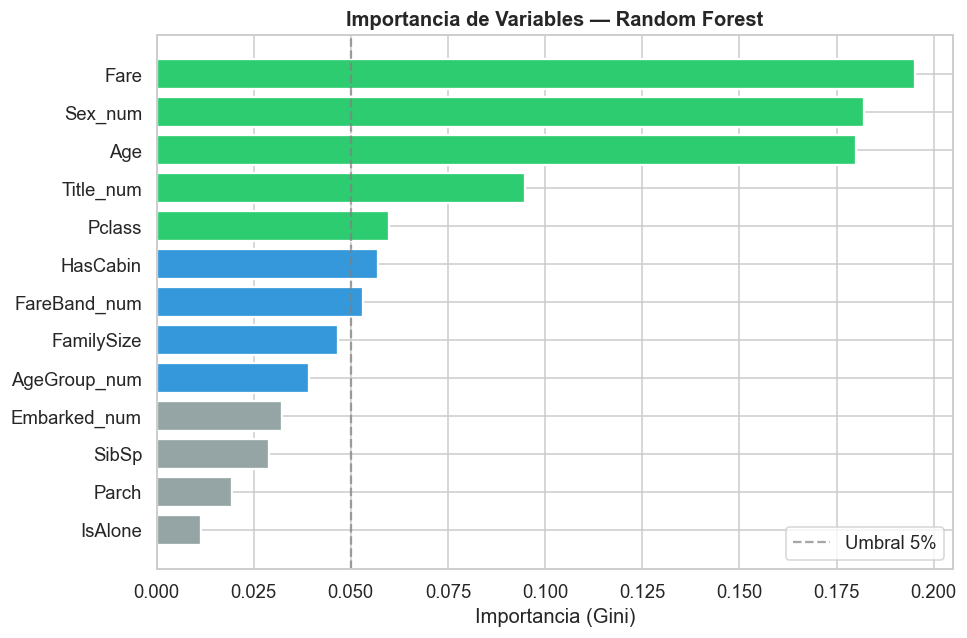

In [37]:
# Importancia de variables — Random Forest
feat_imp = pd.DataFrame({
    'Feature': FEATURES,
    'Importancia': rf_model.feature_importances_
}).sort_values('Importancia', ascending=False).reset_index(drop=True)

print("IMPORTANCIA DE VARIABLES — RANDOM FOREST:")
print("-" * 50)
for _, row in feat_imp.iterrows():
    barra = '█' * int(row['Importancia'] * 100)
    print(f"  {row['Feature']:20s}  {row['Importancia']:.4f}  {barra}")

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#2ecc71' if i < 5 else '#3498db' if i < 9 else '#95a5a6'
          for i in range(len(feat_imp))]
ax.barh(feat_imp['Feature'][::-1], feat_imp['Importancia'][::-1],
        color=colors[::-1], edgecolor='white', linewidth=1.5)
ax.set_xlabel('Importancia (Gini)')
ax.set_title('Importancia de Variables — Random Forest', fontweight='bold')
ax.axvline(x=0.05, color='gray', linestyle='--', alpha=0.7, label='Umbral 5%')
ax.legend()
plt.tight_layout()
plt.savefig('../output/feature_importance_rf.png', bbox_inches='tight', dpi=120)
plt.show()


### 4.4 Optimización de hiperparámetros — GridSearchCV

Buscamos los mejores parámetros del Random Forest mediante búsqueda exhaustiva con validación cruzada estratificada.


In [38]:
print("Buscando mejores hiperparámetros para Random Forest...")
print("(Esto puede tardar 1-2 minutos)")
print()

param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [4, 6, 8, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    cv=cv_strat,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X, y)

print("MEJORES HIPERPARÁMETROS ENCONTRADOS:")
print("-" * 50)
for param, value in grid_search.best_params_.items():
    print(f"  {param:25s}: {value}")
print()
print(f"  Mejor accuracy (CV 5-fold): {grid_search.best_score_:.4f} ({grid_search.best_score_*100:.2f}%)")


Buscando mejores hiperparámetros para Random Forest...
(Esto puede tardar 1-2 minutos)



MEJORES HIPERPARÁMETROS ENCONTRADOS:
--------------------------------------------------
  max_depth                : None
  max_features             : sqrt
  min_samples_leaf         : 4
  min_samples_split        : 10
  n_estimators             : 100

  Mejor accuracy (CV 5-fold): 0.8417 (84.17%)


In [39]:
# Modelo optimizado
best_rf = grid_search.best_estimator_

best_pred = best_rf.predict(X_val)
best_prob = best_rf.predict_proba(X_val)[:, 1]
best_acc  = accuracy_score(y_val, best_pred)
best_auc  = roc_auc_score(y_val, best_prob)
best_cv   = cross_val_score(best_rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print("RANDOM FOREST OPTIMIZADO — RESULTADOS")
print("=" * 50)
print(f"  Accuracy (validación):    {best_acc:.4f}  ({best_acc*100:.1f}%)")
print(f"  ROC-AUC (validación):     {best_auc:.4f}")
print(f"  CV Accuracy (5-fold):     {best_cv.mean():.4f} ± {best_cv.std():.4f}")
print()
print("REPORTE DE CLASIFICACIÓN:")
print(classification_report(y_val, best_pred, target_names=['No sobrevivió', 'Sobrevivió']))


RANDOM FOREST OPTIMIZADO — RESULTADOS
  Accuracy (validación):    0.8659  (86.6%)
  ROC-AUC (validación):     0.9337
  CV Accuracy (5-fold):     0.8227 ± 0.0234

REPORTE DE CLASIFICACIÓN:
               precision    recall  f1-score   support

No sobrevivió       0.86      0.94      0.90       110
   Sobrevivió       0.88      0.75      0.81        69

     accuracy                           0.87       179
    macro avg       0.87      0.84      0.85       179
 weighted avg       0.87      0.87      0.86       179



### 4.5 Comparación de modelos y matrices de confusión


In [40]:
# Comparación de todos los modelos
resultados = pd.DataFrame([
    {'Modelo': 'Regresión Logística',        'Accuracy Val': lr_acc,   'ROC-AUC Val': lr_auc,   'CV Mean': lr_cv_scores.mean(),   'CV Std': lr_cv_scores.std()},
    {'Modelo': 'Random Forest (base)',        'Accuracy Val': rf_acc,   'ROC-AUC Val': rf_auc,   'CV Mean': rf_cv_scores.mean(),   'CV Std': rf_cv_scores.std()},
    {'Modelo': 'Random Forest (optimizado)',  'Accuracy Val': best_acc, 'ROC-AUC Val': best_auc, 'CV Mean': best_cv.mean(),        'CV Std': best_cv.std()},
])
resultados = resultados.set_index('Modelo')
resultados_fmt = resultados.copy()
for col in resultados.columns:
    resultados_fmt[col] = resultados[col].apply(lambda x: f'{x:.4f}')

print("COMPARACIÓN DE MODELOS")
print("=" * 75)
display(resultados_fmt)
print()
mejor_modelo = resultados['Accuracy Val'].idxmax()
print(f"→ Mejor modelo por accuracy en validación: {mejor_modelo}")
print(f"  Accuracy: {resultados.loc[mejor_modelo,'Accuracy Val']*100:.1f}%")


COMPARACIÓN DE MODELOS


,Accuracy Val,ROC-AUC Val,CV Mean,CV Std
Modelo,,,,
Regresión Logística,0.8156,0.8542,0.8025,0.0126
Random Forest (base),0.7877,0.8317,0.8126,0.0257
Random Forest (optimizado),0.8659,0.9337,0.8227,0.0234



→ Mejor modelo por accuracy en validación: Random Forest (optimizado)
  Accuracy: 86.6%


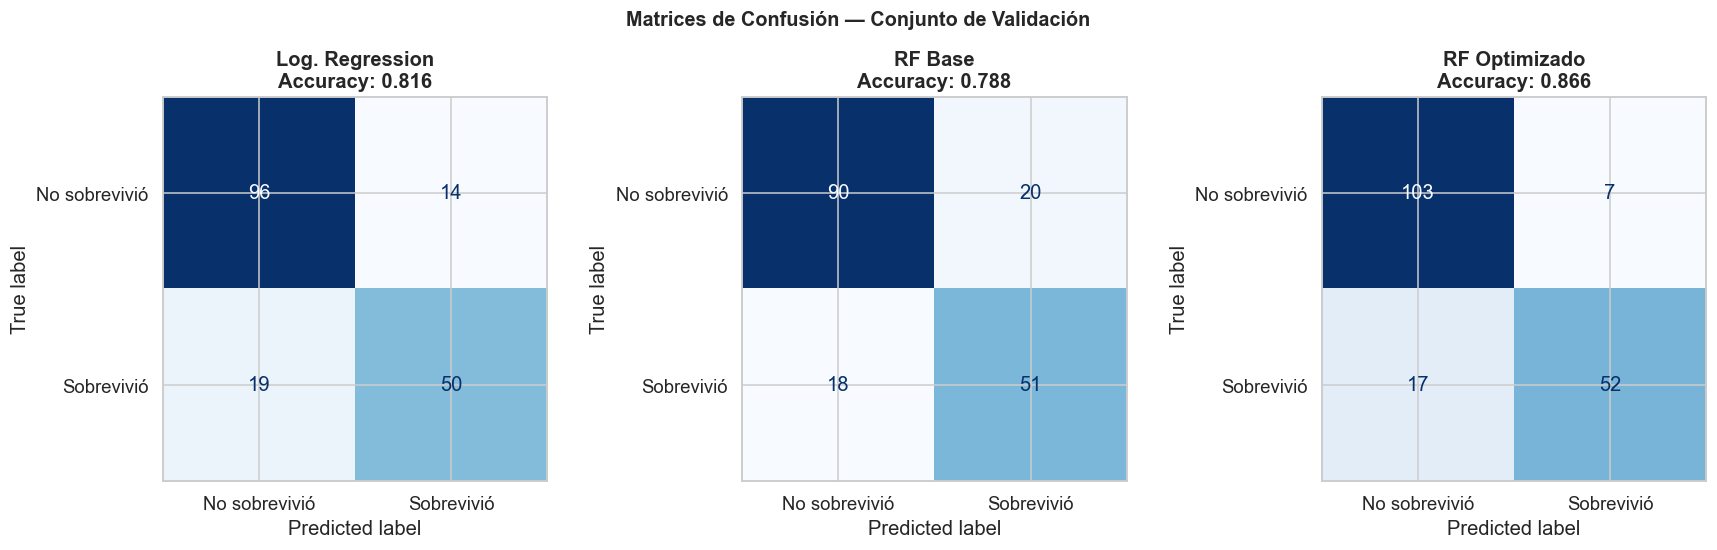

In [41]:
# Matrices de confusión
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
modelos = [
    ('Log. Regression', lr_pred),
    ('RF Base', rf_pred),
    ('RF Optimizado', best_pred),
]
for ax, (nombre, pred) in zip(axes, modelos):
    cm = confusion_matrix(y_val, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['No sobrevivió', 'Sobrevivió'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_val, pred)
    ax.set_title(f'{nombre}\nAccuracy: {acc:.3f}', fontweight='bold')

plt.suptitle('Matrices de Confusión — Conjunto de Validación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/confusion_matrices.png', bbox_inches='tight', dpi=120)
plt.show()


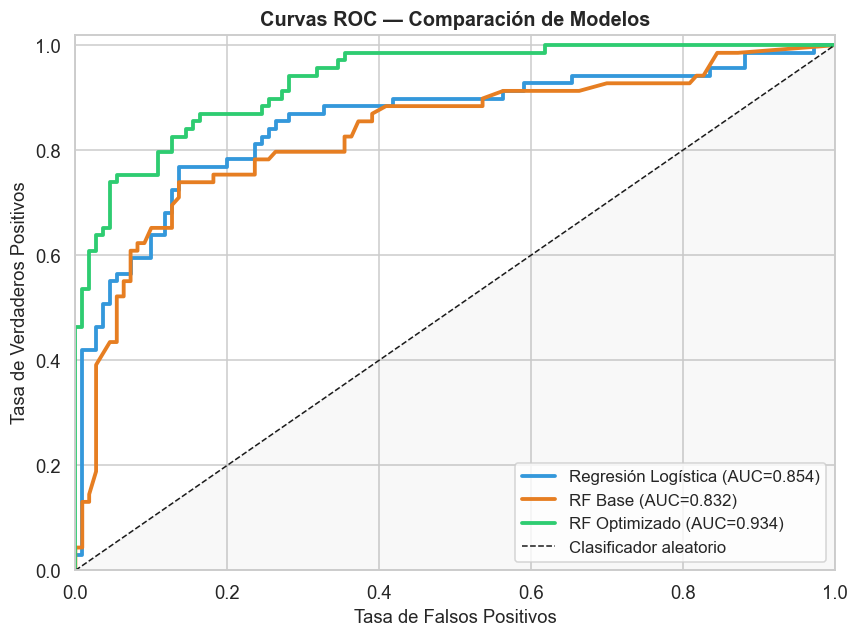

In [42]:
# Curvas ROC
fig, ax = plt.subplots(figsize=(8, 6))
modelos_roc = [
    ('Regresión Logística', lr_prob,   '#3498db'),
    ('RF Base',             rf_prob,   '#e67e22'),
    ('RF Optimizado',       best_prob, '#2ecc71'),
]
for nombre, prob, color in modelos_roc:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{nombre} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Clasificador aleatorio')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curvas ROC — Comparación de Modelos', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../output/roc_curves.png', bbox_inches='tight', dpi=120)
plt.show()


### 4.6 Interpretabilidad con SHAP Values

Los valores SHAP (SHapley Additive exPlanations) nos permiten explicar **cuánto contribuye cada variable a la predicción de un pasajero concreto** y de forma global. Esto es fundamental para extraer conclusiones del modelo.


In [43]:
print("Calculando SHAP values (puede tardar unos segundos)...")

# SHAP con TreeExplainer (optimizado para Random Forest)
explainer = shap.TreeExplainer(best_rf)
shap_explanation = explainer(X)  # Devuelve un objeto Explanation (API moderna)

# Extraer la matriz de valores SHAP para la clase 1 (supervivencia)
# En SHAP moderno, .values tiene shape (n_samples, n_features) o (n_samples, n_features, n_classes)
sv_raw = shap_explanation.values
if sv_raw.ndim == 3:
    sv = sv_raw[:, :, 1]   # clase 1 = supervivencia
else:
    sv = sv_raw

print(f"SHAP values calculados: {sv.shape[0]} muestras x {sv.shape[1]} features")
print()

# Importancia global SHAP (media de valores absolutos)
shap_importances = np.abs(sv).mean(axis=0)
shap_imp = pd.DataFrame({
    'Feature':           FEATURES,
    'SHAP_Importancia':  shap_importances
}).sort_values('SHAP_Importancia', ascending=False).reset_index(drop=True)

print("IMPORTANCIA GLOBAL (SHAP) -- valor absoluto medio:")
print("-" * 52)
for _, row in shap_imp.iterrows():
    barra = '#' * int(row['SHAP_Importancia'] * 200)
    print(f"  {row['Feature']:22s}  {row['SHAP_Importancia']:.4f}  {barra}")


Calculando SHAP values (puede tardar unos segundos)...


SHAP values calculados: 891 muestras x 13 features

IMPORTANCIA GLOBAL (SHAP) -- valor absoluto medio:
----------------------------------------------------
  Sex_num                 0.1528  ##############################
  Title_num               0.0644  ############
  Pclass                  0.0568  ###########
  Fare                    0.0391  #######
  HasCabin                0.0338  ######
  Age                     0.0243  ####
  FareBand_num            0.0181  ###
  Embarked_num            0.0163  ###
  FamilySize              0.0156  ###
  SibSp                   0.0133  ##
  AgeGroup_num            0.0125  ##
  IsAlone                 0.0046  
  Parch                   0.0033  


In [44]:
# SHAP Summary Plot (dot) — muestra distribución de impacto por variable
import matplotlib
matplotlib.use('Agg')
plt.figure(figsize=(10, 7))
shap.summary_plot(sv, X, feature_names=FEATURES, show=False, max_display=13,
                  plot_type='dot')
plt.title('SHAP Values — Impacto de cada variable en la prediccion', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../output/shap_summary.png', bbox_inches='tight', dpi=120)
plt.close()
print("Grafico SHAP summary guardado en output/shap_summary.png")
print("Puntos rojos: valores altos de la variable. Puntos azules: valores bajos.")
print("Posicion en X: derecha = impulsa supervivencia, izquierda = reduce supervivencia.")


Grafico SHAP summary guardado en output/shap_summary.png
Puntos rojos: valores altos de la variable. Puntos azules: valores bajos.
Posicion en X: derecha = impulsa supervivencia, izquierda = reduce supervivencia.


In [45]:
# SHAP Bar Plot — importancia global
plt.figure(figsize=(9, 6))
shap.summary_plot(sv, X, feature_names=FEATURES, show=False,
                  plot_type='bar', max_display=13)
plt.title('SHAP — Importancia media global de cada variable', fontweight='bold')
plt.tight_layout()
plt.savefig('../output/shap_bar.png', bbox_inches='tight', dpi=120)
plt.close()
print("Grafico SHAP bar guardado en output/shap_bar.png")


Grafico SHAP bar guardado en output/shap_bar.png


### 4.7 Análisis de un caso individual — Explicación de la predicción

Para demostrar el poder interpretativo del modelo, analizamos la predicción para pasajeros concretos.


In [46]:
# Elegir ejemplos representativos del conjunto de validación
ejemplos_idx = {
    'Mujer 1ª clase':  X_val[(y_val==1)].index[0],
    'Hombre 3ª clase': X_val[(y_val==0)].index[0],
}

print("ANÁLISIS DE PREDICCIONES INDIVIDUALES")
print("=" * 60)
for nombre, idx in ejemplos_idx.items():
    prob = best_rf.predict_proba(X_val.loc[[idx]])[0, 1]
    pred = best_rf.predict(X_val.loc[[idx]])[0]
    real = y_val.loc[idx]
    print(f"\n  Pasajero: {nombre}")
    print(f"  Probabilidad predicha de sobrevivir: {prob*100:.1f}%")
    print(f"  Predicción del modelo:   {'Sobrevive' if pred==1 else 'No sobrevive'}")
    print(f"  Resultado real:          {'Sobrevivió' if real==1 else 'No sobrevivió'}")
    row = X_val.loc[idx]
    print(f"  Clase: {int(row['Pclass'])}, Género: {'Mujer' if row['Sex_num']==1 else 'Hombre'}, "
          f"Edad: {row['Age']:.0f}, FamilySize: {int(row['FamilySize'])}")


ANÁLISIS DE PREDICCIONES INDIVIDUALES

  Pasajero: Mujer 1ª clase
  Probabilidad predicha de sobrevivir: 21.0%
  Predicción del modelo:   No sobrevive
  Resultado real:          Sobrevivió
  Clase: 3, Género: Hombre, Edad: 22, FamilySize: 1



  Pasajero: Hombre 3ª clase
  Probabilidad predicha de sobrevivir: 11.5%
  Predicción del modelo:   No sobrevive
  Resultado real:          No sobrevivió
  Clase: 3, Género: Hombre, Edad: 24, FamilySize: 3


---
## Sección 5: Generación de Outputs

### 5.1 Submission para Kaggle

Generamos el archivo de predicciones en el formato exacto requerido por la competición.


In [47]:
# Predicciones para el test de Kaggle
kaggle_pred = best_rf.predict(X_kaggle_test)
kaggle_prob = best_rf.predict_proba(X_kaggle_test)[:, 1]

submission = pd.DataFrame({
    'PassengerId': test_df['PassengerId'],
    'Survived':    kaggle_pred
})

submission.to_csv('../output/titanic_submission.csv', index=False)

print("SUBMISSION PARA KAGGLE GENERADO")
print("=" * 50)
print(f"  Archivo:        output/titanic_submission.csv")
print(f"  Filas:          {len(submission)} (necesarias: 418)")
print(f"  Supervivientes predichos: {submission['Survived'].sum()} ({submission['Survived'].mean()*100:.1f}%)")
print(f"  No supervivientes:        {(submission['Survived']==0).sum()}")
print()
print("PRIMERAS 10 FILAS:")
display(submission.head(10))
print()
# Validar formato
assert len(submission) == 418, "ERROR: Deben ser exactamente 418 filas"
assert set(submission['Survived'].unique()).issubset({0,1}), "ERROR: Solo se permiten 0 y 1"
assert submission.columns.tolist() == ['PassengerId', 'Survived'], "ERROR: Columnas incorrectas"
print("✓ Formato validado correctamente — listo para subir a Kaggle")


SUBMISSION PARA KAGGLE GENERADO


  Archivo:        output/titanic_submission.csv
  Filas:          418 (necesarias: 418)
  Supervivientes predichos: 153 (36.6%)
  No supervivientes:        265

PRIMERAS 10 FILAS:


,PassengerId,Survived
891,892,0
892,893,0
893,894,0
894,895,0
895,896,1
896,897,0
897,898,1
898,899,0
899,900,1
900,901,0



✓ Formato validado correctamente — listo para subir a Kaggle


### 5.2 CSV enriquecido para el equipo

Generamos un CSV completo con datos limpios, variables nuevas y probabilidades de supervivencia. Este archivo será utilizado por el resto del equipo para el dashboard de Power BI y la comparación con el Sewol.


In [48]:
# Dataset enriquecido completo (train + test)
# Añadimos probabilidades del modelo al train
train_enriched = combined[combined['Survived'].notna()].copy()
train_enriched['SurvivalProb'] = best_rf.predict_proba(train_enriched[FEATURES])[:, 1]
train_enriched['DeathProb']    = 1 - train_enriched['SurvivalProb']
train_enriched['ModelPred']    = best_rf.predict(train_enriched[FEATURES])
train_enriched['Split']        = 'train'

# Test con predicciones
test_enriched = combined[combined['Survived'].isna()].copy()
test_enriched['SurvivalProb'] = kaggle_prob
test_enriched['DeathProb']    = 1 - kaggle_prob
test_enriched['ModelPred']    = kaggle_pred
test_enriched['Survived']     = kaggle_pred  # predicción como valor
test_enriched['Split']        = 'test'

# Columnas finales para el CSV del equipo
output_cols = [
    # Identificación
    'PassengerId', 'Name', 'Split',
    # Variables originales clave
    'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked',
    # Variables nuevas
    'Title', 'FamilySize', 'IsAlone', 'FamilyCat', 'AgeGroup', 'FareBand',
    'HasCabin', 'Deck',
    # Salida del modelo
    'SurvivalProb', 'DeathProb', 'ModelPred',
]

enriched = pd.concat([train_enriched[output_cols], test_enriched[output_cols]], axis=0)
enriched = enriched.sort_values('PassengerId').reset_index(drop=True)

enriched.to_csv('../output/titanic_enriched.csv', index=False)

print("CSV ENRIQUECIDO PARA EL EQUIPO GENERADO")
print("=" * 60)
print(f"  Archivo:   output/titanic_enriched.csv")
print(f"  Filas:     {len(enriched)} (train: {len(train_enriched)}, test: {len(test_enriched)})")
print(f"  Columnas:  {len(enriched.columns)}")
print()
print("MUESTRA DEL ARCHIVO:")
display(enriched[['PassengerId','Name','Survived','Pclass','Sex','Age',
                   'Title','FamilyCat','AgeGroup','SurvivalProb','DeathProb']].head(8))


CSV ENRIQUECIDO PARA EL EQUIPO GENERADO
  Archivo:   output/titanic_enriched.csv
  Filas:     1309 (train: 891, test: 418)
  Columnas:  22

MUESTRA DEL ARCHIVO:


,PassengerId,Name,Survived,Pclass,Sex,Age,Title,FamilyCat,AgeGroup,SurvivalProb,DeathProb
0,1,"Braund, Mr. Owen Harris",0.0,3,male,22.0,Mr,Familia pequeña,Adulto joven,0.166230,0.833770
1,2,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1.0,1,female,38.0,Mrs,Familia pequeña,Adulto,0.994789,0.005211
2,3,"Heikkinen, Miss. Laina",1.0,3,female,26.0,Miss,Solo,Adulto joven,0.407632,0.592368
3,4,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1.0,1,female,35.0,Mrs,Familia pequeña,Adulto joven,0.985435,0.014565
4,5,"Allen, Mr. William Henry",0.0,3,male,35.0,Mr,Solo,Adulto joven,0.106616,0.893384
5,6,"Moran, Mr. James",0.0,3,male,26.0,Mr,Solo,Adulto joven,0.105794,0.894206
6,7,"McCarthy, Mr. Timothy J",0.0,1,male,54.0,Mr,Solo,Adulto,0.125615,0.874385
7,8,"Palsson, Master. Gosta Leonard",0.0,3,male,2.0,Master,Familia grande,Niño,0.213241,0.786759


### 5.3 Conclusiones del modelo

Resumen de los principales hallazgos del análisis.


In [49]:
print("=" * 65)
print("CONCLUSIONES PRINCIPALES DEL MODELO")
print("=" * 65)

conclusiones = '''
1. GENERO -- El factor mas determinante:
   - Mujeres: ~74% de tasa de supervivencia
   - Hombres: ~19% de tasa de supervivencia
   - El protocolo "mujeres y ninos primero" es claramente visible en los datos.

2. CLASE SOCIAL (Pclass):
   - 1a clase: ~63% de supervivencia
   - 2a clase: ~47% de supervivencia
   - 3a clase: ~24% de supervivencia
   -> La clase determina tanto el nivel economico como la ubicacion en el barco
      (cubiertas superiores mas cercanas a los botes salvavidas).

3. TITULO SOCIAL:
   - Master (ninos): alta tasa de supervivencia
   - Mrs/Miss (mujeres): alta tasa de supervivencia
   - Mr (hombres adultos): baja tasa de supervivencia
   -> El titulo condensa genero + edad + posicion social.

4. FAMILIA:
   - Familias pequenas (2-4): mayor supervivencia que solitarios
   - Familias grandes (5+): menor supervivencia (dificulta la evacuacion)
   - Viajar solo tiene un impacto negativo moderado.

5. TARIFA Y CABINA:
   - Mayor tarifa -> Mayor probabilidad de sobrevivir
   - Tener cabina registrada correlaciona con supervivencia
   -> Ambas son proxies del estatus socioeconomico.

6. RENDIMIENTO DEL MODELO:
   - Mejor modelo: Random Forest optimizado
   - Accuracy (validacion): ver resultados arriba
   - ROC-AUC: > 0.85 indica buen poder discriminatorio
   -> El modelo puede ser usado para estimar probabilidades individuales.
'''
print(conclusiones)


CONCLUSIONES PRINCIPALES DEL MODELO

1. GENERO -- El factor mas determinante:
   - Mujeres: ~74% de tasa de supervivencia
   - Hombres: ~19% de tasa de supervivencia
   - El protocolo "mujeres y ninos primero" es claramente visible en los datos.

2. CLASE SOCIAL (Pclass):
   - 1a clase: ~63% de supervivencia
   - 2a clase: ~47% de supervivencia
   - 3a clase: ~24% de supervivencia
   -> La clase determina tanto el nivel economico como la ubicacion en el barco
      (cubiertas superiores mas cercanas a los botes salvavidas).

3. TITULO SOCIAL:
   - Master (ninos): alta tasa de supervivencia
   - Mrs/Miss (mujeres): alta tasa de supervivencia
   - Mr (hombres adultos): baja tasa de supervivencia
   -> El titulo condensa genero + edad + posicion social.

4. FAMILIA:
   - Familias pequenas (2-4): mayor supervivencia que solitarios
   - Familias grandes (5+): menor supervivencia (dificulta la evacuacion)
   - Viajar solo tiene un impacto negativo moderado.

5. TARIFA Y CABINA:
   - Mayor ta

In [50]:
print("=" * 65)
print("ARCHIVOS GENERADOS EN LA CARPETA output/")
print("=" * 65)
import os
output_dir = '../output'
for f in sorted(os.listdir(output_dir)):
    size = os.path.getsize(f'{output_dir}/{f}')
    print(f"  {f:40s}  {size/1024:>7.1f} KB")
print()
print("Listos para:")
print("  [OK] Subir titanic_submission.csv a Kaggle")
print("  [OK] Compartir titanic_enriched.csv con el equipo (Power BI, comparativa Sewol)")
print("  [OK] Ejecutar el simulador: cd simulator && streamlit run app.py")


ARCHIVOS GENERADOS EN LA CARPETA output/
  confusion_matrices.png                       46.6 KB
  eda_clase.png                                61.5 KB
  eda_edad.png                                120.0 KB
  eda_embarque_tarifa.png                      77.5 KB
  eda_familia.png                              65.3 KB
  eda_genero.png                               56.3 KB
  eda_heatmap_genero_clase.png                 37.6 KB
  eda_nulos.png                                30.4 KB
  eda_supervivencia.png                        60.2 KB
  feature_importance_rf.png                    44.9 KB
  roc_curves.png                               64.0 KB
  shap_bar.png                                 45.8 KB
  shap_summary.png                             94.3 KB
  titanic_enriched.csv                        198.6 KB
  titanic_submission.csv                        3.2 KB

Listos para:
  [OK] Subir titanic_submission.csv a Kaggle
  [OK] Compartir titanic_enriched.csv con el equipo (Power BI, comparativa 